# Module 1 - Graph basics: Queries, Algorithms & Vectors  

This module has the following objectives:
- Creating a Graph from Structured Data
- Basic Cypher Queries and Pattern Matching
- Graph Algorithms
- Text Embeddings for Semantic Analysis
- Vector Search

In [4]:
# Install required packages for research area extraction with Gemini AI
# !pip install graphdatascience neo4j python-dotenv langchain langchain_openai matplotlib seaborn
# !pip install google-generativeai pandas requests

Import our usual suspects (and some more...)

In [46]:
import os
import pandas as pd
from dotenv import load_dotenv
from graphdatascience import GraphDataScience
from neo4j import Query, GraphDatabase, RoutingControl, Result
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

# Additional imports for advanced ML-based research area extraction
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.cluster import KMeans, DBSCAN
    from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
    from sklearn.decomposition import LatentDirichletAllocation
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    import umap
    import numpy as np
    from collections import Counter
    import re
    import warnings
    warnings.filterwarnings('ignore')
    
    # Try to import transformers for BERT-based classification
    try:
        from transformers import pipeline
        TRANSFORMERS_AVAILABLE = True
        print("✅ Transformers library available for BERT-based classification")
    except ImportError:
        TRANSFORMERS_AVAILABLE = False
        print("⚠️  Transformers library not available. Install with: pip install transformers")
    
    # Try to import plotly for interactive visualizations
    try:
        import plotly.express as px
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        PLOTLY_AVAILABLE = True
        print("✅ Plotly available for interactive visualizations")
    except ImportError:
        PLOTLY_AVAILABLE = False
        print("⚠️  Plotly not available. Install with: pip install plotly")
        
    ML_LIBRARIES_AVAILABLE = True
    print("✅ Advanced ML libraries loaded successfully")
    
except ImportError as e:
    ML_LIBRARIES_AVAILABLE = False
    print(f"⚠️  Some ML libraries not available: {e}")
    print("💡 Install with: pip install sentence-transformers scikit-learn umap-learn transformers torch")
    print("📝 Falling back to basic keyword-based research area extraction")

✅ Transformers library available for BERT-based classification
✅ Plotly available for interactive visualizations
✅ Advanced ML libraries loaded successfully


## Setup

Load env variables

In [57]:
env_file = 'ws.env'

In [58]:
if os.path.exists(env_file):
    load_dotenv(env_file, override=True)

    # Neo4j
    HOST = os.getenv('NEO4J_URI')
    USERNAME = os.getenv('NEO4J_USERNAME')
    PASSWORD = os.getenv('NEO4J_PASSWORD')
    DATABASE = os.getenv('NEO4J_DATABASE')

    # Api Github
    GITHUB_TOKEN = os.getenv('GITHUB_TOKEN')

    # AI
    GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
    os.environ['GEMINI_API_KEY']=GEMINI_API_KEY
    LLM = os.getenv('LLM')
    EMBEDDINGS_MODEL = os.getenv('EMBEDDINGS_MODEL')
else:
    print(f"File {env_file} not found.")

## Read Data

Load synthetic Skills dataset

In [49]:
# Function untuk load semua data UNESA dari GitHub dengan clean structure
def load_unesa_datasets():
    """
    Load semua dataset UNESA dari GitHub repository
    Returns: Dictionary berisi semua dataframes dan list dataset yang gagal di-load
    """
    
    # Define all dataset URLs dengan nama yang clean
    dataset_config = {
        'penelitian': 'penelitian.csv',
        'dosen': 'dosen.csv', 
        'karya': 'karya.csv',
        'mengajar': 'mengajar.csv',
        'paten': 'paten.csv',
        'pengabdian': 'pengabdian.csv',
        'studi': 'studi.csv',
        'unesa_activities': 'unesa_activities.csv',
        'unesa_courses': 'unesa_courses.csv',
        'jadwal_kuliah_s1_sains_data': 'jadwal_kuliah_s1_sains_data.csv'
    }
    
    base_url = "https://api.github.com/repos/rizkyyanuark/Tugas_Akhir/contents/scraping/file_tabulars/"
    headers = {
        "Authorization": f"token {GITHUB_TOKEN}",
        "Accept": "application/vnd.github.v3.raw"
    }
    
    datasets = {}
    failed_loads = []
    
    print("🚀 Loading UNESA datasets from GitHub...")
    print("-" * 60)
    
    for name, filename in dataset_config.items():
        try:
            url = base_url + filename
            print(f"   📁 Loading {name.replace('_', ' ').title()}...", end=" ")
            
            # Fetch data from GitHub
            response = requests.get(url, headers=headers)
            response.raise_for_status()  # Raise exception for bad status codes
            
            # Load CSV data
            df = pd.read_csv(StringIO(response.text))
            datasets[name] = df
            
            print(f"✅ ({df.shape[0]:,} rows × {df.shape[1]} cols)")
            
        except requests.exceptions.RequestException as e:
            print(f"❌ Request failed: {str(e)[:50]}...")
            failed_loads.append(name)
        except pd.errors.EmptyDataError:
            print(f"❌ Empty or invalid CSV data")
            failed_loads.append(name)
        except Exception as e:
            print(f"❌ Unexpected error: {str(e)[:50]}...")
            failed_loads.append(name)
    
    print("-" * 60)
    print(f"✅ Successfully loaded: {len(datasets)}/{len(dataset_config)} datasets")
    if failed_loads:
        print(f"❌ Failed to load: {', '.join(failed_loads)}")
    print()
    
    return datasets, failed_loads

In [50]:
# Load all datasets
print("🎯 Starting UNESA data loading process...")
datasets, failed_datasets = load_unesa_datasets()

# Extract main datasets untuk mudah diakses
penelitian_df = datasets.get('penelitian', pd.DataFrame())
dosen_df = datasets.get('dosen', pd.DataFrame()) 
mengajar_df = datasets.get('mengajar', pd.DataFrame())
karya_df = datasets.get('karya', pd.DataFrame())
pengabdian_df = datasets.get('pengabdian', pd.DataFrame())

🎯 Starting UNESA data loading process...
🚀 Loading UNESA datasets from GitHub...
------------------------------------------------------------
   📁 Loading Penelitian... ✅ (99 rows × 5 cols)
   📁 Loading Dosen... ✅ (13 rows × 13 cols)
   📁 Loading Karya... ✅ (230 rows × 5 cols)
   📁 Loading Mengajar... ✅ (1,118 rows × 7 cols)
   📁 Loading Paten... ✅ (80 rows × 5 cols)
   📁 Loading Pengabdian... ✅ (68 rows × 5 cols)
   📁 Loading Studi... ✅ (30 rows × 10 cols)
   📁 Loading Unesa Activities... ✅ (5,648 rows × 6 cols)
   📁 Loading Unesa Courses... ✅ (353 rows × 43 cols)
   📁 Loading Jadwal Kuliah S1 Sains Data... ✅ (100 rows × 4 cols)
------------------------------------------------------------
✅ Successfully loaded: 10/10 datasets



Describe the dataset

In [51]:
def validate_and_explore_datasets(datasets):
    """
    Validasi dan eksplorasi dataset dengan output yang ringkas dan informatif
    """
    if not datasets:
        print("Tidak ada dataset untuk divalidasi.")
        return

    print("DATASET VALIDATION & EXPLORATION REPORT")
    print("=" * 60)
    
    validation_results = {}
    summary_data = []

    for name, df in datasets.items():
        if df.empty:
            validation_results[name] = {'status': 'empty'}
            summary_data.append([name, 0, 0, 0, 0, 'Empty'])
            continue

        # Basic statistics
        rows, cols = df.shape
        duplicates = df.duplicated().sum()
        missing = df.isnull().sum().sum()
        missing_pct = (missing / (rows * cols)) * 100 if rows * cols > 0 else 0
        
        # Data type analysis
        numeric_cols = df.select_dtypes(include=['number']).shape[1]
        text_cols = df.select_dtypes(include=['object']).shape[1]
        
        # Specific dataset insights
        special_info = ""
        if name == 'penelitian' and 'nama_dosen' in df.columns:
            unique_dosen = df['nama_dosen'].nunique()
            special_info = f"Dosen: {unique_dosen}"
        elif name == 'dosen' and 'nama_dosen' in df.columns:
            unique_dosen = df['nama_dosen'].nunique()
            special_info = f"Total dosen: {unique_dosen}"
        elif name in ['mengajar', 'jadwal_kuliah_s1_sains_data'] and 'nama_matkul' in df.columns:
            unique_matkul = df['nama_matkul'].nunique()
            special_info = f"Mata kuliah: {unique_matkul}"
        
        validation_results[name] = {
            'status': 'valid',
            'shape': df.shape,
            'duplicates': duplicates,
            'missing_values': missing,
            'missing_percentage': missing_pct
        }
        
        summary_data.append([
            name.replace('_', ' ').title(),
            f"{rows:,}",
            cols,
            f"{duplicates:,}" if duplicates > 0 else "0",
            f"{missing_pct:.1f}%" if missing > 0 else "0%",
            special_info or "OK"
        ])

    # Display summary table
    print(f"{'Dataset':<25} {'Rows':<8} {'Cols':<5} {'Duplicates':<10} {'Missing':<8} {'Info':<20}")
    print("-" * 80)
    for row in summary_data:
        print(f"{row[0]:<25} {row[1]:<8} {row[2]:<5} {row[3]:<10} {row[4]:<8} {row[5]:<20}")
    
    return validation_results

def display_data_quality_report(validation_results):
    """Tampilkan ringkasan kualitas data yang ringkas"""
    print("\nDATA QUALITY SUMMARY")
    print("=" * 40)
    
    total = len(validation_results)
    valid = sum(1 for v in validation_results.values() if v['status'] == 'valid')
    empty = sum(1 for v in validation_results.values() if v['status'] == 'empty')
    
    total_rows = sum(v['shape'][0] for v in validation_results.values() if 'shape' in v)
    total_missing = sum(v['missing_values'] for v in validation_results.values() if 'missing_values' in v)
    total_duplicates = sum(v['duplicates'] for v in validation_results.values() if 'duplicates' in v)
    
    print(f"Total datasets: {total} ({valid} valid, {empty} empty)")
    print(f"Success rate: {valid/total*100:.1f}%")
    print(f"Total records: {total_rows:,}")
    print(f"Data quality: {total_duplicates:,} duplicates, {total_missing:,} missing values")

def explore_dataset_sample(datasets, sample_size=3):
    """
    Tampilkan sample data dari dataset utama
    """
    key_datasets = ['penelitian', 'dosen', 'mengajar']
    
    print("\nDATASET SAMPLES")
    print("=" * 50)
    
    for name in key_datasets:
        if name in datasets and not datasets[name].empty:
            df = datasets[name]
            print(f"\n{name.upper()} (showing {sample_size} rows):")
            
            # Select relevant columns for display
            display_cols = df.columns[:4]  # Show first 4 columns
            sample_df = df[display_cols].head(sample_size)
            
            # Format output untuk readability
            for col in sample_df.columns:
                if sample_df[col].dtype == 'object':
                    sample_df[col] = sample_df[col].astype(str).str[:30] + '...'
            
            print(sample_df.to_string(index=False))

In [52]:
# Run comprehensive dataset validation
if datasets:
    print("Running dataset validation...")
    validation_results = validate_and_explore_datasets(datasets)
    display_data_quality_report(validation_results)
    explore_dataset_sample(datasets)
    
    # Focus on penelitian dataset if available
    if 'penelitian' in datasets and not penelitian_df.empty:
        print(f"\nPENELITIAN DATASET FOCUS")
        print("=" * 40)
        
        if 'judul_kegiatan' in penelitian_df.columns:
            print("Sample research titles:")
            titles_sample = penelitian_df['judul_kegiatan'].dropna().head(3).tolist()
            for i, title in enumerate(titles_sample, 1):
                title_clean = title[:60] + "..." if len(title) > 60 else title
                print(f"  {i}. {title_clean}")
        
        if 'nama_dosen' in penelitian_df.columns:
            print("\nTop 5 most active researchers:")
            top_researchers = penelitian_df['nama_dosen'].value_counts().head(5)
            for dosen, count in top_researchers.items():
                print(f"  {dosen}: {count} projects")
else:
    print("No datasets available for validation.")

Running dataset validation...
DATASET VALIDATION & EXPLORATION REPORT
Dataset                   Rows     Cols  Duplicates Missing  Info                
--------------------------------------------------------------------------------
Penelitian                99       5     0          0%       Dosen: 13           
Dosen                     13       13    0          3.0%     Total dosen: 13     
Karya                     230      5     0          0%       OK                  
Mengajar                  1,118    7     3          0.1%     Mata kuliah: 168    
Paten                     80       5     0          0%       OK                  
Pengabdian                68       5     0          0%       OK                  
Studi                     30       10    0          3.3%     OK                  
Unesa Activities          5,648    6     0          0.0%     OK                  
Unesa Courses             353      43    0          1.6%     OK                  
Jadwal Kuliah S1 Sains Data 1

In [59]:
# Test Environment Variables dan Gemini Connection
def test_environment_setup():
    """Test semua environment variables dan koneksi API"""
    
    print("ENVIRONMENT SETUP VALIDATION")
    print("=" * 50)
    
    # Test basic variables
    print(f"Neo4j URI: {HOST if 'HOST' in globals() else 'NOT SET'}")
    print(f"Neo4j Username: {USERNAME if 'USERNAME' in globals() else 'NOT SET'}")
    print(f"Neo4j Database: {DATABASE if 'DATABASE' in globals() else 'NOT SET'}")
    print(f"GitHub Token: {'SET' if 'GITHUB_TOKEN' in globals() and GITHUB_TOKEN else 'NOT SET'}")
    print(f"Gemini API Key: {'SET' if 'GEMINI_API_KEY' in globals() and GEMINI_API_KEY else 'NOT SET'}")
    
    # Test Gemini connection
    if 'GEMINI_API_KEY' in globals() and GEMINI_API_KEY:
        try:
            import google.generativeai as genai
            genai.configure(api_key=GEMINI_API_KEY)
            
            # List available models
            models = list(genai.list_models())
            print("\nAvailable Gemini Models:")
            available_models = []
            for model in models:
                if 'generateContent' in model.supported_generation_methods:
                    model_name = model.name
                    available_models.append(model_name)
                    print(f"  - {model_name}")
                    if len(available_models) >= 5:  # Show max 5 models
                        break
            
            if available_models:
                print(f"\nGemini API: CONNECTED ({len(available_models)} models available)")
                return available_models[0]  # Return first available model
            else:
                print("\nGemini API: NO SUITABLE MODELS FOUND")
                return None
                
        except Exception as e:
            print(f"\nGemini API Connection Error: {str(e)[:100]}...")
            return None
    else:
        print("\nGemini API: NOT CONFIGURED")
        return None

# Test environment setup
print("Testing environment configuration...")
available_gemini_model = test_environment_setup()
print("\nEnvironment test complete!")

Testing environment configuration...
ENVIRONMENT SETUP VALIDATION
Neo4j URI: neo4j://localhost:7687
Neo4j Username: neo4j
Neo4j Database: datascience
GitHub Token: SET
Gemini API Key: SET

Available Gemini Models:
  - models/gemini-2.5-pro-preview-03-25
  - models/gemini-2.5-flash-preview-05-20
  - models/gemini-2.5-flash
  - models/gemini-2.5-flash-lite-preview-06-17
  - models/gemini-2.5-pro-preview-05-06

Gemini API: CONNECTED (5 models available)

Environment test complete!


In [62]:
# Free Open Source Research Area Extractor - No API Keys Required!
import pandas as pd
import numpy as np
from collections import Counter
import re
from typing import List, Dict, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Optional: Try to use lightweight transformers models if available
try:
    from transformers import pipeline, AutoTokenizer, AutoModel
    import torch
    TRANSFORMERS_AVAILABLE = True
    print("✅ Transformers available - akan menggunakan model BERT ringan")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️  Transformers tidak tersedia - menggunakan TF-IDF clustering")

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
    print("✅ SentenceTransformers available - akan menggunakan embedding model")
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("⚠️  SentenceTransformers tidak tersedia - menggunakan alternatif")

class FreeResearchAreaExtractor:
    """
    Ekstraksi research area menggunakan model gratis dan open source
    Tidak memerlukan API key apapun!
    """
    
    def __init__(self):
        self.cs_categories = [
            "Machine Learning & Artificial Intelligence",
            "Computer Vision & Image Processing", 
            "Natural Language Processing",
            "Data Science & Analytics",
            "Software Engineering & Web Development",
            "Database Systems & Information Management",
            "Educational Technology & E-Learning",
            "Healthcare Informatics & Medical AI",
            "Cybersecurity & Information Security",
            "Mobile Computing & Applications",
            "Network Analysis & Social Media",
            "Signal Processing & Multimedia"
        ]
        
        # Enhanced keyword mapping dengan bahasa Indonesia dan English
        self.keyword_mapping = {
            'Machine Learning & Artificial Intelligence': [
                'machine learning', 'ml', 'artificial intelligence', 'ai', 'neural network', 
                'deep learning', 'algoritma', 'prediksi', 'klasifikasi', 'clustering',
                'decision tree', 'random forest', 'support vector', 'regression',
                'kecerdasan buatan', 'pembelajaran mesin', 'jaringan saraf'
            ],
            'Computer Vision & Image Processing': [
                'computer vision', 'image processing', 'citra', 'visual', 'deteksi', 
                'pengenalan', 'segmentasi', 'face recognition', 'object detection',
                'opencv', 'pengolahan citra', 'pengenalan pola', 'face detection'
            ],
            'Natural Language Processing': [
                'natural language processing', 'nlp', 'text mining', 'sentiment analysis', 
                'bahasa alami', 'teks', 'chatbot', 'text classification', 'tokenization',
                'pemrosesan bahasa', 'analisis sentimen', 'text analytics'
            ],
            'Data Science & Analytics': [
                'data mining', 'analytics', 'analisis data', 'big data', 'statistik',
                'data science', 'visualization', 'dashboard', 'business intelligence',
                'data analysis', 'exploratory data', 'statistical analysis'
            ],
            'Educational Technology & E-Learning': [
                'e-learning', 'pendidikan', 'pembelajaran', 'edukasi', 'mahasiswa', 
                'education', 'lms', 'learning management', 'educational system',
                'sistem pembelajaran', 'teknologi pendidikan', 'modul pembelajaran'
            ],
            'Healthcare Informatics & Medical AI': [
                'kesehatan', 'medis', 'health', 'medical', 'covid', 'penyakit',
                'hospital', 'patient', 'diagnosis', 'clinical', 'healthcare',
                'sistem kesehatan', 'rekam medis'
            ],
            'Software Engineering & Web Development': [
                'web', 'website', 'aplikasi', 'software', 'sistem informasi', 
                'mobile', 'android', 'ios', 'framework', 'application',
                'pengembangan aplikasi', 'sistem aplikasi', 'web application'
            ],
            'Database Systems & Information Management': [
                'database', 'basis data', 'mysql', 'postgresql', 'mongodb',
                'data warehouse', 'information system', 'sistem informasi',
                'manajemen data', 'penyimpanan data'
            ],
            'Cybersecurity & Information Security': [
                'security', 'keamanan', 'cyber', 'encryption', 'authentication',
                'firewall', 'intrusion detection', 'vulnerability', 'malware',
                'keamanan informasi', 'keamanan sistem'
            ],
            'Mobile Computing & Applications': [
                'mobile', 'android', 'ios', 'smartphone', 'aplikasi mobile',
                'mobile development', 'flutter', 'react native', 'kotlin', 'swift'
            ],
            'Network Analysis & Social Media': [
                'network', 'social media', 'twitter', 'facebook', 'instagram',
                'social network analysis', 'graph analysis', 'media sosial',
                'analisis jaringan', 'jejaring sosial'
            ],
            'Signal Processing & Multimedia': [
                'signal processing', 'audio', 'video', 'multimedia', 'sound',
                'speech recognition', 'image enhancement', 'digital signal',
                'pemrosesan sinyal', 'pengolahan audio'
            ]
        }
        
        self.model = None
        self.classifier = None
        self.vectorizer = None
        
        # Initialize available models
        self._initialize_models()
    
    def _initialize_models(self):
        """Initialize available free models"""
        print("🚀 Initializing free research area extraction models...")
        
        # Method 1: Try SentenceTransformers (lightweight multilingual model)
        if SENTENCE_TRANSFORMERS_AVAILABLE:
            try:
                # Use a lightweight multilingual model
                self.model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
                print("✅ Loaded SentenceTransformer model: paraphrase-multilingual-MiniLM-L12-v2")
                return
            except Exception as e:
                print(f"⚠️  SentenceTransformer loading failed: {e}")
        
        # Method 2: Try Hugging Face transformers (zero-shot classification)
        if TRANSFORMERS_AVAILABLE:
            try:
                # Use a free multilingual model for zero-shot classification
                self.classifier = pipeline(
                    "zero-shot-classification",
                    model="facebook/bart-large-mnli",
                    device=-1  # Use CPU to avoid GPU memory issues
                )
                print("✅ Loaded Hugging Face zero-shot classifier")
                return
            except Exception as e:
                print(f"⚠️  Hugging Face model loading failed: {e}")
        
        # Method 3: Fallback to TF-IDF + clustering
        print("📊 Using TF-IDF + K-Means clustering as fallback method")
        self.vectorizer = TfidfVectorizer(
            max_features=1000,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 3),
            stop_words=['dan', 'pada', 'untuk', 'dengan', 'dalam', 'dari', 'ke', 'di', 'yang', 'oleh']
        )
    
    def extract_research_areas(self, titles: List[str]) -> Dict[str, List[str]]:
        """
        Main method untuk ekstraksi research areas
        """
        print(f"\n🔬 Extracting research areas for {len(titles)} titles...")
        
        # Method prioritization
        if self.model is not None:
            return self._extract_with_sentence_transformers(titles)
        elif self.classifier is not None:
            return self._extract_with_zero_shot(titles)
        else:
            return self._extract_with_enhanced_keywords(titles)
    
    def _extract_with_sentence_transformers(self, titles: List[str]) -> Dict[str, List[str]]:
        """Extract using SentenceTransformers + similarity matching"""
        print("🤖 Using SentenceTransformer embeddings method...")
        
        # Create embeddings for titles
        title_embeddings = self.model.encode(titles, show_progress_bar=True)
        
        # Create embeddings for category descriptions
        category_descriptions = [
            f"{category}: {' '.join(keywords[:10])}" 
            for category, keywords in self.keyword_mapping.items()
        ]
        category_embeddings = self.model.encode(category_descriptions)
        
        results = {}
        
        for i, title in enumerate(titles):
            # Calculate similarity with each category
            similarities = cosine_similarity(
                [title_embeddings[i]], category_embeddings
            )[0]
            
            # Get top 2 most similar categories
            top_indices = np.argsort(similarities)[-2:][::-1]
            top_categories = []
            
            for idx in top_indices:
                if similarities[idx] > 0.3:  # Threshold for relevance
                    top_categories.append(self.cs_categories[idx])
            
            if not top_categories:
                top_categories = [self.cs_categories[np.argmax(similarities)]]
            
            results[title] = top_categories[:2]
        
        return results
    
    def _extract_with_zero_shot(self, titles: List[str]) -> Dict[str, List[str]]:
        """Extract using Hugging Face zero-shot classification"""
        print("🤖 Using Hugging Face zero-shot classification...")
        
        results = {}
        batch_size = 5  # Process in small batches to avoid memory issues
        
        for i in range(0, len(titles), batch_size):
            batch_titles = titles[i:i+batch_size]
            print(f"Processing batch {i//batch_size + 1}/{(len(titles)-1)//batch_size + 1}")
            
            for title in batch_titles:
                try:
                    result = self.classifier(title, self.cs_categories)
                    
                    # Get top 2 categories with confidence > 0.3
                    top_categories = []
                    for label, score in zip(result['labels'][:2], result['scores'][:2]):
                        if score > 0.3:
                            top_categories.append(label)
                    
                    if not top_categories:
                        top_categories = [result['labels'][0]]
                    
                    results[title] = top_categories
                    
                except Exception as e:
                    print(f"Error processing: {title[:50]}... -> Using keyword fallback")
                    results[title] = self._classify_single_title_keywords(title)
        
        return results
    
    def _extract_with_enhanced_keywords(self, titles: List[str]) -> Dict[str, List[str]]:
        """Enhanced keyword-based extraction with TF-IDF clustering"""
        print("📊 Using enhanced keyword matching + TF-IDF clustering...")
        
        results = {}
        
        # Step 1: Direct keyword matching
        for title in titles:
            results[title] = self._classify_single_title_keywords(title)
        
        # Step 2: TF-IDF clustering for better grouping
        try:
            # Vectorize titles
            tfidf_matrix = self.vectorizer.fit_transform(titles)
            
            # Perform clustering
            n_clusters = min(len(self.cs_categories), len(titles))
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(tfidf_matrix)
            
            # Map clusters to research areas based on keywords
            cluster_to_area = self._map_clusters_to_areas(titles, cluster_labels)
            
            # Refine results using clustering
            for i, title in enumerate(titles):
                cluster = cluster_labels[i]
                if cluster in cluster_to_area:
                    # Combine keyword and cluster results
                    keyword_areas = results[title]
                    cluster_area = cluster_to_area[cluster]
                    
                    if cluster_area not in keyword_areas:
                        results[title] = keyword_areas + [cluster_area]
                    
                    # Limit to top 2
                    results[title] = results[title][:2]
        
        except Exception as e:
            print(f"TF-IDF clustering failed: {e}. Using pure keyword matching.")
        
        return results
    
    def _classify_single_title_keywords(self, title: str) -> List[str]:
        """Classify a single title using keyword matching"""
        title_lower = title.lower()
        category_scores = {}
        
        # Enhanced scoring with word importance
        for category, keywords in self.keyword_mapping.items():
            score = 0
            for keyword in keywords:
                if keyword in title_lower:
                    # Give higher score for exact matches and important terms
                    if len(keyword) > 5:  # Longer keywords are more specific
                        score += 2
                    else:
                        score += 1
            
            if score > 0:
                category_scores[category] = score
        
        # Get top matching categories
        if category_scores:
            sorted_categories = sorted(category_scores.items(), key=lambda x: x[1], reverse=True)
            matched_areas = [cat for cat, score in sorted_categories[:2]]
        else:
            # Fallback: use simple keyword presence
            matched_areas = ["General Computer Science"]
        
        return matched_areas if matched_areas else ["General Computer Science"]
    
    def _map_clusters_to_areas(self, titles: List[str], cluster_labels: np.ndarray) -> Dict[int, str]:
        """Map cluster labels to research areas"""
        cluster_to_area = {}
        
        for cluster_id in set(cluster_labels):
            cluster_titles = [titles[i] for i in range(len(titles)) if cluster_labels[i] == cluster_id]
            
            # Count keyword occurrences in this cluster
            area_votes = Counter()
            for title in cluster_titles:
                title_areas = self._classify_single_title_keywords(title)
                for area in title_areas:
                    area_votes[area] += 1
            
            # Assign the most voted area to this cluster
            if area_votes:
                cluster_to_area[cluster_id] = area_votes.most_common(1)[0][0]
        
        return cluster_to_area

# Replace the Gemini extraction with free method
def extract_research_areas_free(titles: List[str]) -> Dict[str, List[str]]:
    """
    Free research area extraction - No API key required!
    """
    extractor = FreeResearchAreaExtractor()
    return extractor.extract_research_areas(titles)

def analyze_research_areas_distribution(title_to_areas: Dict[str, List[str]]) -> None:
    """
    Analyze research areas distribution
    """
    
    print("\nRESEARCH AREAS DISTRIBUTION ANALYSIS")
    print("=" * 50)
    
    # Flatten all areas
    all_areas = []
    for areas in title_to_areas.values():
        all_areas.extend(areas)
    
    area_counts = Counter(all_areas)
    total_assignments = len(all_areas)
    
    print(f"Total penelitian: {len(title_to_areas)}")
    print(f"Total area assignments: {total_assignments}")
    print(f"Unique research areas: {len(area_counts)}")
    
    print("\nArea distribution:")
    for area, count in area_counts.most_common():
        percentage = (count / total_assignments) * 100
        print(f"  {area}: {count} penelitian ({percentage:.1f}%)")

# Main execution dengan free method
if 'penelitian_df' in locals() and not penelitian_df.empty and 'judul_kegiatan' in penelitian_df.columns:
    print("🎯 Starting FREE research area extraction (No API required)...")
    
    # Get research titles
    research_titles = penelitian_df['judul_kegiatan'].dropna().tolist()
    print(f"Processing {len(research_titles)} research titles")
    
    # Extract research areas using FREE method
    title_to_areas_free = extract_research_areas_free(research_titles)
    
    # Add results to dataframe
    penelitian_df['research_areas'] = penelitian_df['judul_kegiatan'].map(title_to_areas_free)
    
    # Analyze distribution
    analyze_research_areas_distribution(title_to_areas_free)
    
    # Show sample results
    print("\nSAMPLE EXTRACTION RESULTS:")
    print("=" * 50)
    
    sample_count = 0
    for idx, row in penelitian_df.iterrows():
        if pd.notna(row['judul_kegiatan']) and sample_count < 8:
            title = row['judul_kegiatan']
            areas = row['research_areas']
            print(f"\n{sample_count + 1}. Title: {title[:70]}..." if len(title) > 70 else f"\n{sample_count + 1}. Title: {title}")
            print(f"   Areas: {areas}")
            sample_count += 1
    
    print(f"\n" + "=" * 50)
    print(f"✅ FREE research area extraction completed for {len(title_to_areas_free)} titles!")
    print("🎉 No API keys required - completely FREE and OFFLINE!")
    
else:
    print("Research dataset not available or missing 'judul_kegiatan' column.")
    print("Please run the dataset loading cell first.")

✅ Transformers available - akan menggunakan model BERT ringan
✅ SentenceTransformers available - akan menggunakan embedding model
🎯 Starting FREE research area extraction (No API required)...
Processing 99 research titles
🚀 Initializing free research area extraction models...
✅ Loaded SentenceTransformer model: paraphrase-multilingual-MiniLM-L12-v2

🔬 Extracting research areas for 99 titles...
🤖 Using SentenceTransformer embeddings method...


Batches: 100%|███████████████████████████████████████████████████████████████████████████| 4/4 [00:02<00:00,  1.79it/s]



RESEARCH AREAS DISTRIBUTION ANALYSIS
Total penelitian: 56
Total area assignments: 84
Unique research areas: 12

Area distribution:
  Machine Learning & Artificial Intelligence: 11 penelitian (13.1%)
  Computer Vision & Image Processing: 11 penelitian (13.1%)
  Educational Technology & E-Learning: 11 penelitian (13.1%)
  Software Engineering & Web Development: 10 penelitian (11.9%)
  Cybersecurity & Information Security: 8 penelitian (9.5%)
  Database Systems & Information Management: 8 penelitian (9.5%)
  Data Science & Analytics: 7 penelitian (8.3%)
  Network Analysis & Social Media: 7 penelitian (8.3%)
  Mobile Computing & Applications: 4 penelitian (4.8%)
  Signal Processing & Multimedia: 3 penelitian (3.6%)
  Natural Language Processing: 2 penelitian (2.4%)
  Healthcare Informatics & Medical AI: 2 penelitian (2.4%)

SAMPLE EXTRACTION RESULTS:

1. Title: Analisis dan Pengolahan Data Kesetaraan Gender dalam Pengerjaan Tugas-...
   Areas: ['Data Science & Analytics']

2. Title: Predi

Creating research areas visualization...


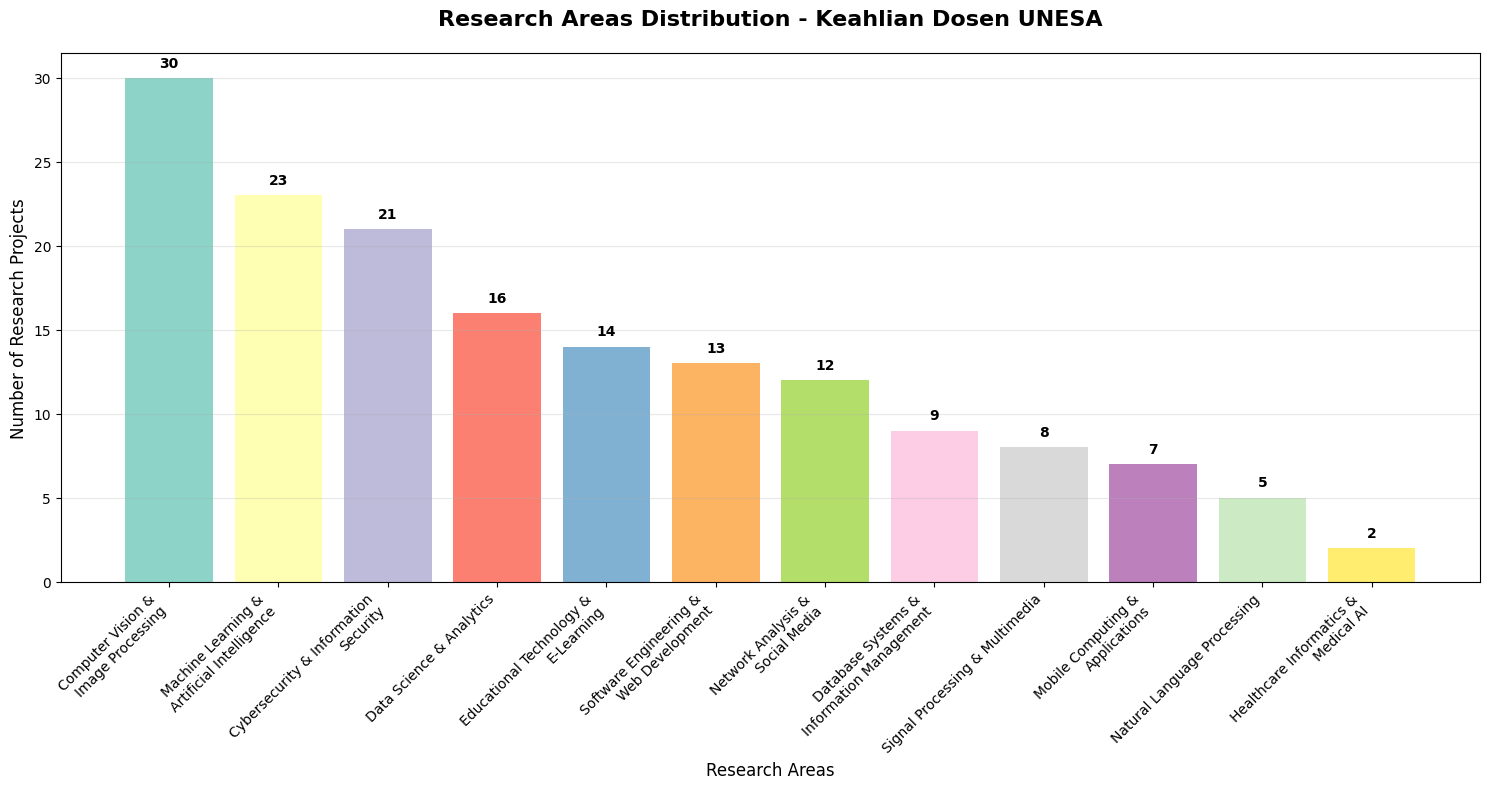


VISUALIZATION SUMMARY:
- Total research area assignments: 160
- Unique research areas: 12
- Most common area: Computer Vision & Image Processing (30 projects)

Analyzing dosen expertise...

DOSEN EXPERTISE ANALYSIS
TOP 15 MOST ACTIVE RESEARCHERS:
--------------------------------------------------------------------------------
No  Nama Dosen                     Projects Diversity Primary Expertise        
--------------------------------------------------------------------------------
1   Riskyana Dewi Intan Puspitas   20       10        Computer Vision & Imag...
2   Hasanuddin Al-habib            19       10        Educational Technology...
3   Ibnu Febry Kurniawan           19       8         Computer Vision & Imag...
4   Yuliani Puji Astuti            18       7         Machine Learning & Art...
5   Elly Matul Imah                18       7         Computer Vision & Imag...
6   Atik Wintarti                  16       9         Cybersecurity & Inform...
7   Fadhilah Qalbi Annisa     

In [63]:
# Visualisasi dan Analisis Research Areas
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def visualize_research_areas(penelitian_df):
    """
    Create visualization of research areas distribution
    """
    
    if 'research_areas' not in penelitian_df.columns:
        print("Research areas column not found. Run Gemini extraction first.")
        return
    
    # Collect all research areas
    all_areas = []
    for areas in penelitian_df['research_areas'].dropna():
        if isinstance(areas, list):
            all_areas.extend(areas)
        elif isinstance(areas, str):
            all_areas.append(areas)
    
    if not all_areas:
        print("No research areas found.")
        return
    
    area_counts = Counter(all_areas)
    
    try:
        # Create matplotlib visualization
        top_areas = dict(area_counts.most_common(12))
        
        plt.figure(figsize=(15, 8))
        
        # Create bar plot
        bars = plt.bar(range(len(top_areas)), list(top_areas.values()), 
                      color=plt.cm.Set3(range(len(top_areas))))
        
        # Formatting
        plt.title('Research Areas Distribution - Keahlian Dosen UNESA', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Research Areas', fontsize=12)
        plt.ylabel('Number of Research Projects', fontsize=12)
        
        # Format x-axis labels
        area_labels = []
        for area in top_areas.keys():
            if len(area) > 30:
                # Split long area names
                words = area.split(' ')
                if len(words) > 3:
                    area_label = ' '.join(words[:3]) + '\n' + ' '.join(words[3:])
                else:
                    area_label = area.replace(' & ', '\n&\n')
            else:
                area_label = area
            area_labels.append(area_label)
        
        plt.xticks(range(len(top_areas)), area_labels, rotation=45, ha='right', fontsize=10)
        
        # Add value labels on bars
        for i, (bar, count) in enumerate(zip(bars, top_areas.values())):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{count}', ha='center', va='bottom', fontweight='bold')
        
        # Add grid
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        total_research = len(all_areas)
        unique_areas = len(area_counts)
        most_common = area_counts.most_common(1)[0]
        
        print(f"\nVISUALIZATION SUMMARY:")
        print(f"- Total research area assignments: {total_research}")
        print(f"- Unique research areas: {unique_areas}")
        print(f"- Most common area: {most_common[0]} ({most_common[1]} projects)")
        
    except ImportError:
        # Text-based fallback
        print("\nRESEARCH AREAS DISTRIBUTION:")
        print("=" * 60)
        
        max_count = area_counts.most_common(1)[0][1]
        for i, (area, count) in enumerate(area_counts.most_common(15)):
            bar_length = int((count / max_count) * 30)
            bar = "|" * bar_length
            print(f"{i+1:2d}. {area:<35} {bar} {count}")
        
        print(f"\nTotal: {len(area_counts)} areas, {sum(area_counts.values())} assignments")

def analyze_dosen_expertise(penelitian_df):
    """
    Analyze expertise for each dosen
    """
    
    if 'research_areas' not in penelitian_df.columns or 'nama_dosen' not in penelitian_df.columns:
        print("Required columns not found.")
        return
    
    print("\nDOSEN EXPERTISE ANALYSIS")
    print("=" * 60)
    
    # Group by dosen
    dosen_expertise = {}
    
    for idx, row in penelitian_df.iterrows():
        if pd.notna(row['nama_dosen']):
            areas = row.get('research_areas')
            if areas is not None and (isinstance(areas, list) or pd.notna(areas)):
                dosen = row['nama_dosen']
                areas = areas if isinstance(areas, list) else [areas]
                
                if dosen not in dosen_expertise:
                    dosen_expertise[dosen] = []
                dosen_expertise[dosen].extend(areas)
    
    # Analyze each dosen
    dosen_summary = []
    for dosen, areas in dosen_expertise.items():
        area_counts = Counter(areas)
        primary_area = area_counts.most_common(1)[0][0] if area_counts else "Unknown"
        research_count = len(areas)
        diversity = len(set(areas))
        
        dosen_summary.append({
            'nama': dosen,
            'total_penelitian': research_count,
            'primary_expertise': primary_area,
            'expertise_diversity': diversity,
            'area_distribution': dict(area_counts)
        })
    
    # Sort by research count and diversity
    dosen_summary.sort(key=lambda x: (x['total_penelitian'], x['expertise_diversity']), reverse=True)
    
    # Display top researchers
    print("TOP 15 MOST ACTIVE RESEARCHERS:")
    print("-" * 80)
    print(f"{'No':<3} {'Nama Dosen':<30} {'Projects':<8} {'Diversity':<9} {'Primary Expertise':<25}")
    print("-" * 80)
    
    for i, dosen in enumerate(dosen_summary[:15]):
        primary_short = dosen['primary_expertise'][:22] + "..." if len(dosen['primary_expertise']) > 25 else dosen['primary_expertise']
        print(f"{i+1:<3} {dosen['nama'][:28]:<30} {dosen['total_penelitian']:<8} {dosen['expertise_diversity']:<9} {primary_short:<25}")
    
    # Research areas summary
    all_primary_areas = [d['primary_expertise'] for d in dosen_summary]
    primary_counts = Counter(all_primary_areas)
    
    print(f"\nPRIMARY EXPERTISE SUMMARY:")
    print("-" * 50)
    for area, count in primary_counts.most_common(10):
        percentage = (count / len(dosen_summary)) * 100
        print(f"{area}: {count} dosen ({percentage:.1f}%)")
    
    return dosen_summary

# Run visualization and analysis if data is available
if 'penelitian_df' in locals() and not penelitian_df.empty and 'research_areas' in penelitian_df.columns:
    print("Creating research areas visualization...")
    visualize_research_areas(penelitian_df)
    
    print("\nAnalyzing dosen expertise...")
    dosen_summary = analyze_dosen_expertise(penelitian_df)
    
else:
    print("Research areas data not available. Run Gemini extraction first.")

In [64]:
# Analisis Keahlian Dosen berdasarkan Research Areas
def analyze_dosen_expertise(df):
    """Analisis keahlian setiap dosen berdasarkan research areas"""
    
    print("👨‍🏫 Analisis Keahlian Dosen berdasarkan Research Areas\n")
    
    # Group by dosen and aggregate research areas
    dosen_expertise = df.groupby('nama_dosen').agg({
        'research_areas': lambda x: [area for areas in x for area in areas],  # Flatten all areas
        'judul_kegiatan': 'count',
        'tahun_kegiatan': lambda x: f"{min(x)}-{max(x)}" if len(set(x)) > 1 else str(list(x)[0])
    }).reset_index()
    
    dosen_expertise.columns = ['nama_dosen', 'all_research_areas', 'jumlah_penelitian', 'periode_penelitian']
    
    # Calculate expertise areas for each dosen
    expertise_data = []
    
    for idx, row in dosen_expertise.iterrows():
        areas = row['all_research_areas']
        area_counts = Counter(areas)
        
        # Determine primary and secondary expertise
        sorted_areas = area_counts.most_common()
        primary_expertise = sorted_areas[0][0] if sorted_areas else "Unknown"
        secondary_expertise = [area for area, count in sorted_areas[1:3]]  # Top 2-3 secondary areas
        
        expertise_data.append({
            'nama_dosen': row['nama_dosen'],
            'jumlah_penelitian': row['jumlah_penelitian'],
            'periode_penelitian': row['periode_penelitian'],
            'primary_expertise': primary_expertise,
            'secondary_expertise': secondary_expertise,
            'all_areas': list(area_counts.keys()),
            'area_distribution': dict(area_counts),
            'expertise_diversity': len(set(areas))  # Number of different research areas
        })
    
    expertise_df = pd.DataFrame(expertise_data)
    
    # Sort by research diversity and quantity
    expertise_df = expertise_df.sort_values(['expertise_diversity', 'jumlah_penelitian'], ascending=[False, False])
    
    return expertise_df

def display_top_researchers_by_area(expertise_df, top_n=5):
    """Display top researchers for each research area"""
    
    print("🏆 Top Researchers by Research Area:\n")
    
    # Get all unique research areas
    all_areas = set()
    for areas in expertise_df['all_areas']:
        all_areas.update(areas)
    
    for area in sorted(all_areas):
        print(f"📍 {area}:")
        
        # Find researchers who have this area
        area_researchers = []
        for idx, row in expertise_df.iterrows():
            if area in row['area_distribution']:
                count = row['area_distribution'][area]
                area_researchers.append({
                    'nama': row['nama_dosen'],
                    'count': count,
                    'total_penelitian': row['jumlah_penelitian'],
                    'periode': row['periode_penelitian']
                })
        
        # Sort by count and total research
        area_researchers.sort(key=lambda x: (x['count'], x['total_penelitian']), reverse=True)
        
        # Display top researchers for this area
        for i, researcher in enumerate(area_researchers[:top_n]):
            print(f"   {i+1}. {researcher['nama']} - {researcher['count']} penelitian ({researcher['total_penelitian']} total, {researcher['periode']})")
        
        print()

def generate_dosen_expertise_summary(expertise_df):
    """Generate summary of dosen expertise"""
    
    print("📊 Summary Keahlian Dosen:\n")
    
    # Overall statistics
    total_dosen = len(expertise_df)
    avg_penelitian = expertise_df['jumlah_penelitian'].mean()
    avg_diversity = expertise_df['expertise_diversity'].mean()
    
    print(f"👥 Total Dosen: {total_dosen}")
    print(f"📚 Rata-rata Penelitian per Dosen: {avg_penelitian:.1f}")
    print(f"🎯 Rata-rata Keberagaman Area: {avg_diversity:.1f}")
    
    # Top diverse researchers
    print(f"\n🌟 Top 10 Most Diverse Researchers:")
    for idx, row in expertise_df.head(10).iterrows():
        areas_str = ", ".join(row['all_areas'][:3])  # Show first 3 areas
        if len(row['all_areas']) > 3:
            areas_str += f" (+{len(row['all_areas'])-3} more)"
        
        print(f"   {row['nama_dosen']}: {row['expertise_diversity']} areas - {areas_str}")
    
    # Primary expertise distribution
    primary_counts = Counter(expertise_df['primary_expertise'])
    print(f"\n🎯 Primary Expertise Distribution:")
    for expertise, count in primary_counts.most_common():
        percentage = (count / total_dosen) * 100
        print(f"   {expertise}: {count} dosen ({percentage:.1f}%)")

# Analyze dosen expertise
print("🔍 Menganalisis keahlian dosen...")
expertise_df = analyze_dosen_expertise(penelitian_df)

# Display results
generate_dosen_expertise_summary(expertise_df)
display_top_researchers_by_area(expertise_df, top_n=3)

# Display detailed expertise for some researchers
print("📋 Detail Keahlian Beberapa Dosen Terpilih:\n")
for idx, row in expertise_df.head(5).iterrows():
    print(f"👨‍🔬 {row['nama_dosen']}:")
    print(f"   📊 Total Penelitian: {row['jumlah_penelitian']}")
    print(f"   📅 Periode: {row['periode_penelitian']}")
    print(f"   🎯 Primary Expertise: {row['primary_expertise']}")
    if row['secondary_expertise']:
        print(f"   🔄 Secondary Expertise: {', '.join(row['secondary_expertise'])}")
    print(f"   📈 Area Distribution: {row['area_distribution']}")
    print(f"   🌟 Diversity Score: {row['expertise_diversity']}")
    print()

expertise_df.head(10)

🔍 Menganalisis keahlian dosen...
👨‍🏫 Analisis Keahlian Dosen berdasarkan Research Areas

📊 Summary Keahlian Dosen:

👥 Total Dosen: 13
📚 Rata-rata Penelitian per Dosen: 7.6
🎯 Rata-rata Keberagaman Area: 6.7

🌟 Top 10 Most Diverse Researchers:
   Hasanuddin Al-habib: 10 areas - Data Science & Analytics, Computer Vision & Image Processing, Cybersecurity & Information Security (+7 more)
   Riskyana Dewi Intan Puspitasari: 10 areas - Machine Learning & Artificial Intelligence, Network Analysis & Social Media, Computer Vision & Image Processing (+7 more)
   Atik Wintarti: 9 areas - Data Science & Analytics, Machine Learning & Artificial Intelligence, Network Analysis & Social Media (+6 more)
   Ibnu Febry Kurniawan: 8 areas - Cybersecurity & Information Security, Computer Vision & Image Processing, Machine Learning & Artificial Intelligence (+5 more)
   Yuliani Puji Astuti: 7 areas - Machine Learning & Artificial Intelligence, Computer Vision & Image Processing, Cybersecurity & Information S

,nama_dosen,jumlah_penelitian,periode_penelitian,primary_expertise,secondary_expertise,all_areas,area_distribution,expertise_diversity
5,Hasanuddin Al-habib,11,2023-2025,Educational Technology & E-Learning,"[Computer Vision & Image Processing, Data Scie...","[Data Science & Analytics, Computer Vision & I...","{'Data Science & Analytics': 2, 'Computer Visi...",10
9,Riskyana Dewi Intan Puspitasari,10,2023-2025,Computer Vision & Image Processing,"[Machine Learning & Artificial Intelligence, C...","[Machine Learning & Artificial Intelligence, N...",{'Machine Learning & Artificial Intelligence':...,10
0,Atik Wintarti,11,2020-2025,Cybersecurity & Information Security,"[Data Science & Analytics, Machine Learning & ...","[Data Science & Analytics, Machine Learning & ...","{'Data Science & Analytics': 2, 'Machine Learn...",9
6,Ibnu Febry Kurniawan,12,2015-2025,Computer Vision & Image Processing,"[Cybersecurity & Information Security, Network...","[Cybersecurity & Information Security, Compute...","{'Cybersecurity & Information Security': 3, 'C...",8
11,Yuliani Puji Astuti,12,2014-2024,Machine Learning & Artificial Intelligence,"[Database Systems & Information Management, Ed...","[Machine Learning & Artificial Intelligence, C...",{'Machine Learning & Artificial Intelligence':...,7
2,Elly Matul Imah,11,2019-2025,Computer Vision & Image Processing,"[Cybersecurity & Information Security, Signal ...","[Computer Vision & Image Processing, Signal Pr...","{'Computer Vision & Image Processing': 7, 'Sig...",7
7,Ike Fitriyaningsih,10,2016-2025,Machine Learning & Artificial Intelligence,"[Data Science & Analytics, Software Engineerin...","[Data Science & Analytics, Machine Learning & ...","{'Data Science & Analytics': 2, 'Machine Learn...",7
3,Fadhilah Qalbi Annisa,7,2023-2025,Computer Vision & Image Processing,"[Cybersecurity & Information Security, Softwar...","[Computer Vision & Image Processing, Cybersecu...","{'Computer Vision & Image Processing': 5, 'Cyb...",7
10,Ulfa Siti Nuraini,4,2024-2025,Computer Vision & Image Processing,"[Data Science & Analytics, Signal Processing &...","[Data Science & Analytics, Computer Vision & I...","{'Data Science & Analytics': 1, 'Computer Visi...",6
4,Harmon Prayogi,3,2024,Machine Learning & Artificial Intelligence,"[Computer Vision & Image Processing, Mobile Co...","[Machine Learning & Artificial Intelligence, C...",{'Machine Learning & Artificial Intelligence':...,6


📊 Membuat visualisasi research areas dan expertise...


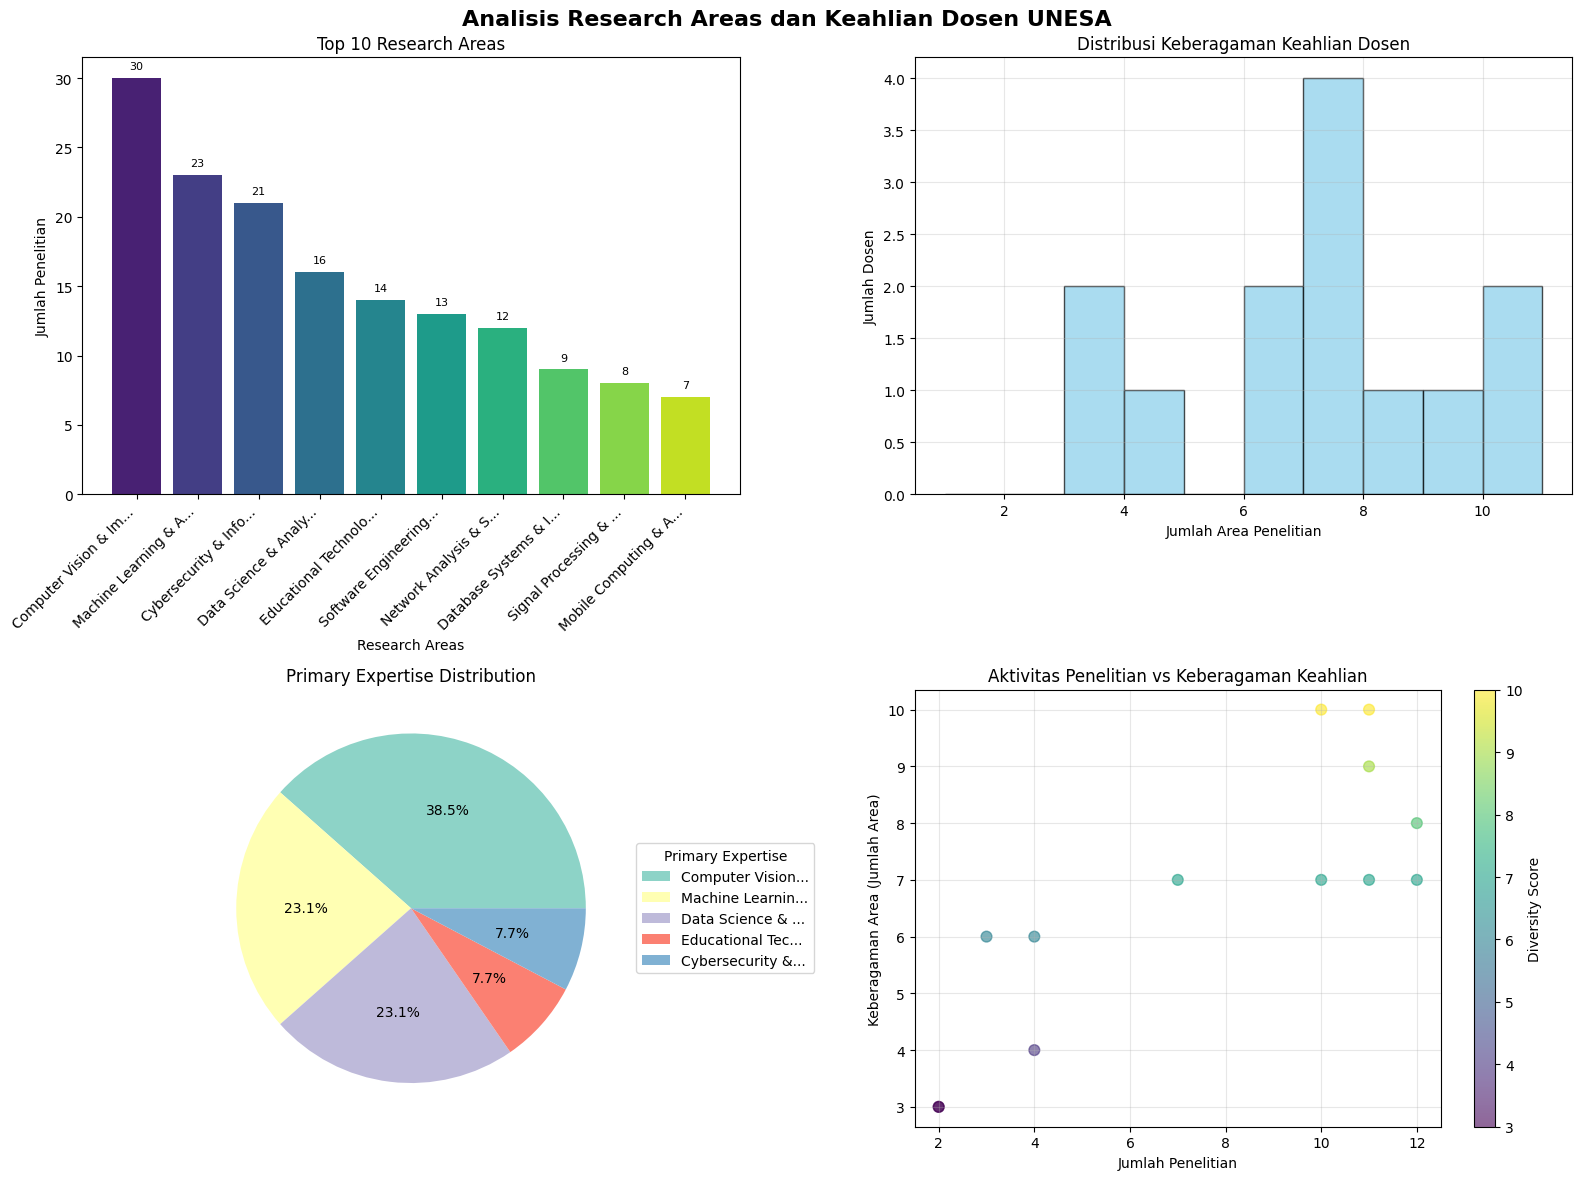

🔗 Expertise Network Summary:

📊 Network Statistics:
   Nodes (Dosen): 13
   Nodes (Research Areas): 12
   Edges (Connections): 87
   Average connections per dosen: 6.7

🌟 Most Connected Research Areas:
   Machine Learning & Artificial Intelligence: 12 dosen, 23 penelitian, 3 sebagai primary
   Data Science & Analytics: 10 dosen, 16 penelitian, 3 sebagai primary
   Cybersecurity & Information Security: 9 dosen, 21 penelitian, 1 sebagai primary
   Computer Vision & Image Processing: 9 dosen, 30 penelitian, 5 sebagai primary
   Network Analysis & Social Media: 8 dosen, 12 penelitian, 0 sebagai primary
   Educational Technology & E-Learning: 8 dosen, 14 penelitian, 1 sebagai primary
   Software Engineering & Web Development: 7 dosen, 13 penelitian, 0 sebagai primary
   Mobile Computing & Applications: 7 dosen, 7 penelitian, 0 sebagai primary
   Signal Processing & Multimedia: 6 dosen, 8 penelitian, 0 sebagai primary
   Database Systems & Information Management: 5 dosen, 9 penelitian, 0 seb

In [65]:
# Visualisasi Research Areas dan Expertise Dosen
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

def create_research_area_visualizations(penelitian_df, expertise_df):
    """Create comprehensive visualizations for research areas and expertise"""
    
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Analisis Research Areas dan Keahlian Dosen UNESA', fontsize=16, fontweight='bold')
    
    # 1. Research Areas Distribution (Bar Chart)
    all_areas = []
    for areas in penelitian_df['research_areas']:
        all_areas.extend(areas)
    
    area_counts = Counter(all_areas)
    top_areas = dict(area_counts.most_common(10))
    
    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(top_areas)), list(top_areas.values()), 
                   color=sns.color_palette("viridis", len(top_areas)))
    ax1.set_xlabel('Research Areas')
    ax1.set_ylabel('Jumlah Penelitian')
    ax1.set_title('Top 10 Research Areas')
    ax1.set_xticks(range(len(top_areas)))
    ax1.set_xticklabels([area[:20]+'...' if len(area) > 20 else area 
                        for area in top_areas.keys()], rotation=45, ha='right')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # 2. Dosen Expertise Diversity (Histogram)
    ax2 = axes[0, 1]
    ax2.hist(expertise_df['expertise_diversity'], bins=range(1, max(expertise_df['expertise_diversity'])+2), 
             color='skyblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Jumlah Area Penelitian')
    ax2.set_ylabel('Jumlah Dosen')
    ax2.set_title('Distribusi Keberagaman Keahlian Dosen')
    ax2.grid(True, alpha=0.3)
    
    # 3. Primary Expertise Distribution (Pie Chart)
    ax3 = axes[1, 0]
    primary_counts = Counter(expertise_df['primary_expertise'])
    top_primary = dict(primary_counts.most_common(8))
    
    # Combine smaller categories into "Others"
    others_count = sum(primary_counts.values()) - sum(top_primary.values())
    if others_count > 0:
        top_primary['Others'] = others_count
    
    wedges, texts, autotexts = ax3.pie(top_primary.values(), labels=None, autopct='%1.1f%%',
                                      colors=sns.color_palette("Set3", len(top_primary)))
    ax3.set_title('Primary Expertise Distribution')
    
    # Add legend for pie chart
    ax3.legend(wedges, [f"{k[:15]}..." if len(k) > 15 else k for k in top_primary.keys()],
               title="Primary Expertise", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    # 4. Research Activity vs Diversity (Scatter Plot)
    ax4 = axes[1, 1]
    scatter = ax4.scatter(expertise_df['jumlah_penelitian'], expertise_df['expertise_diversity'], 
                         alpha=0.6, s=60, c=expertise_df['expertise_diversity'], 
                         cmap='viridis')
    ax4.set_xlabel('Jumlah Penelitian')
    ax4.set_ylabel('Keberagaman Area (Jumlah Area)')
    ax4.set_title('Aktivitas Penelitian vs Keberagaman Keahlian')
    ax4.grid(True, alpha=0.3)
    
    # Add colorbar for scatter plot
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Diversity Score')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def create_expertise_network_summary(expertise_df):
    """Create a summary table of expertise network"""
    
    print("🔗 Expertise Network Summary:\n")
    
    # Create expertise network data
    network_data = []
    
    for idx, row in expertise_df.iterrows():
        for area in row['all_areas']:
            network_data.append({
                'dosen': row['nama_dosen'],
                'research_area': area,
                'frequency': row['area_distribution'][area],
                'is_primary': (area == row['primary_expertise']),
                'total_research': row['jumlah_penelitian']
            })
    
    network_df = pd.DataFrame(network_data)
    
    # Summary statistics
    print(f"📊 Network Statistics:")
    print(f"   Nodes (Dosen): {len(expertise_df)}")
    print(f"   Nodes (Research Areas): {network_df['research_area'].nunique()}")
    print(f"   Edges (Connections): {len(network_df)}")
    print(f"   Average connections per dosen: {len(network_df) / len(expertise_df):.1f}")
    
    # Most connected research areas
    print(f"\n🌟 Most Connected Research Areas:")
    area_connections = network_df.groupby('research_area').agg({
        'dosen': 'count',
        'frequency': 'sum',
        'is_primary': 'sum'
    }).sort_values('dosen', ascending=False)
    
    area_connections.columns = ['num_dosen', 'total_frequency', 'primary_count']
    
    for area, data in area_connections.head(10).iterrows():
        print(f"   {area}: {data['num_dosen']} dosen, {data['total_frequency']} penelitian, {data['primary_count']} sebagai primary")
    
    return network_df

# Create visualizations
print("📊 Membuat visualisasi research areas dan expertise...")
viz_fig = create_research_area_visualizations(penelitian_df, expertise_df)

# Create network summary
network_df = create_expertise_network_summary(expertise_df)

In [66]:
# Export Hasil dan Laporan Keahlian Dosen
def generate_dosen_expertise_report(expertise_df, output_format='detailed'):
    """Generate comprehensive expertise report for each dosen"""
    
    if output_format == 'detailed':
        print("📑 Laporan Detail Keahlian Dosen UNESA\n")
        print("="*80)
        
        for idx, row in expertise_df.iterrows():
            print(f"\n👨‍🔬 PROFIL KEAHLIAN: {row['nama_dosen'].upper()}")
            print("-" * 60)
            
            print(f"📊 STATISTIK PENELITIAN:")
            print(f"   • Total Penelitian: {row['jumlah_penelitian']} penelitian")
            print(f"   • Periode Aktif: {row['periode_penelitian']}")
            print(f"   • Keberagaman Area: {row['expertise_diversity']} area penelitian")
            
            print(f"\n🎯 AREA KEAHLIAN UTAMA:")
            print(f"   • Primary Expertise: {row['primary_expertise']}")
            
            if row['secondary_expertise']:
                print(f"   • Secondary Expertise: {', '.join(row['secondary_expertise'])}")
            
            print(f"\n📈 DISTRIBUSI PENELITIAN PER AREA:")
            sorted_areas = sorted(row['area_distribution'].items(), 
                                key=lambda x: x[1], reverse=True)
            
            for area, count in sorted_areas:
                percentage = (count / row['jumlah_penelitian']) * 100
                indicator = "🏆" if area == row['primary_expertise'] else "📌"
                print(f"   {indicator} {area}: {count} penelitian ({percentage:.1f}%)")
            
            print("=" * 60)
    
    elif output_format == 'summary':
        # Create summary table
        summary_data = []
        for idx, row in expertise_df.iterrows():
            summary_data.append({
                'Nama Dosen': row['nama_dosen'],
                'Total Penelitian': row['jumlah_penelitian'],
                'Periode': row['periode_penelitian'],
                'Primary Expertise': row['primary_expertise'],
                'Secondary Areas': ', '.join(row['secondary_expertise'][:2]) if row['secondary_expertise'] else '',
                'Diversity Score': row['expertise_diversity']
            })
        
        summary_df = pd.DataFrame(summary_data)
        return summary_df

def create_expertise_recommendations(expertise_df):
    """Create collaboration and development recommendations"""
    
    print("💡 REKOMENDASI BERDASARKAN ANALISIS KEAHLIAN\n")
    
    # 1. Collaboration opportunities
    print("🤝 PELUANG KOLABORASI:")
    
    # Find dosen with complementary expertise
    from itertools import combinations
    collaboration_opportunities = []
    
    for (idx1, dosen1), (idx2, dosen2) in combinations(expertise_df.iterrows(), 2):
        # Check for complementary areas
        areas1 = set(dosen1['all_areas'])
        areas2 = set(dosen2['all_areas'])
        
        # Find intersection and potential synergy
        common_areas = areas1.intersection(areas2)
        unique_areas1 = areas1 - areas2
        unique_areas2 = areas2 - areas1
        
        # Calculate collaboration score
        if len(common_areas) > 0 and (len(unique_areas1) > 0 or len(unique_areas2) > 0):
            score = len(common_areas) + 0.5 * (len(unique_areas1) + len(unique_areas2))
            
            collaboration_opportunities.append({
                'dosen1': dosen1['nama_dosen'],
                'dosen2': dosen2['nama_dosen'],
                'common_areas': list(common_areas),
                'complementary_areas': list(unique_areas1.union(unique_areas2)),
                'score': score
            })
    
    # Sort by collaboration potential
    collaboration_opportunities.sort(key=lambda x: x['score'], reverse=True)
    
    print("   Top 5 Potential Collaborations:")
    for i, collab in enumerate(collaboration_opportunities[:5]):
        print(f"\n   {i+1}. {collab['dosen1']} ↔ {collab['dosen2']}")
        print(f"      Common Areas: {', '.join(collab['common_areas'])}")
        if collab['complementary_areas']:
            print(f"      Complementary: {', '.join(collab['complementary_areas'][:3])}")
        print(f"      Synergy Score: {collab['score']:.1f}")
    
    # 2. Research gap analysis
    print(f"\n🔍 ANALISIS GAP PENELITIAN:")
    
    all_areas = set()
    for areas in expertise_df['all_areas']:
        all_areas.update(areas)
    
    area_coverage = Counter()
    for idx, row in expertise_df.iterrows():
        for area in row['all_areas']:
            area_coverage[area] += 1
    
    # Find underrepresented areas
    total_dosen = len(expertise_df)
    underrepresented = {area: count for area, count in area_coverage.items() 
                       if count < total_dosen * 0.1}  # Less than 10% coverage
    
    if underrepresented:
        print("   Areas that need more researchers:")
        for area, count in sorted(underrepresented.items(), key=lambda x: x[1]):
            print(f"   • {area}: hanya {count} dosen ({count/total_dosen*100:.1f}%)")
    
    # 3. Development recommendations
    print(f"\n📈 REKOMENDASI PENGEMBANGAN:")
    
    # Find dosen who could expand their expertise
    expansion_candidates = []
    for idx, row in expertise_df.iterrows():
        if row['expertise_diversity'] < 3 and row['jumlah_penelitian'] >= 3:
            expansion_candidates.append({
                'nama': row['nama_dosen'],
                'current_diversity': row['expertise_diversity'],
                'primary': row['primary_expertise'],
                'potential': 'High' if row['jumlah_penelitian'] > 5 else 'Medium'
            })
    
    if expansion_candidates:
        print("   Dosen dengan potensi ekspansi keahlian:")
        for candidate in expansion_candidates[:5]:
            print(f"   • {candidate['nama']}: {candidate['current_diversity']} areas, "
                  f"fokus di {candidate['primary']} (potensi: {candidate['potential']})")

def export_results_to_files(penelitian_df, expertise_df):
    """Export analysis results to CSV files"""
    
    print("💾 MENYIMPAN HASIL ANALISIS...\n")
    
    try:
        # Export enhanced research data
        penelitian_df.to_csv('penelitian_with_research_areas.csv', index=False, encoding='utf-8')
        print("✅ Saved: penelitian_with_research_areas.csv")
        
        # Export expertise analysis
        expertise_df.to_csv('dosen_expertise_analysis.csv', index=False, encoding='utf-8')
        print("✅ Saved: dosen_expertise_analysis.csv")
        
        # Create summary report
        summary_df = generate_dosen_expertise_report(expertise_df, output_format='summary')
        summary_df.to_csv('dosen_expertise_summary.csv', index=False, encoding='utf-8')
        print("✅ Saved: dosen_expertise_summary.csv")
        
        print(f"\n📁 Files saved successfully!")
        print(f"   Total dosen analyzed: {len(expertise_df)}")
        print(f"   Total research projects: {len(penelitian_df)}")
        print(f"   Unique research areas identified: {penelitian_df['research_areas'].apply(len).sum()}")
        
    except Exception as e:
        print(f"❌ Error saving files: {e}")

# Generate detailed report
print("📋 Generating expertise reports...")
generate_dosen_expertise_report(expertise_df.head(3), output_format='detailed')

# Create recommendations
create_expertise_recommendations(expertise_df)

# Export results
export_results_to_files(penelitian_df, expertise_df)

# Create summary table
summary_table = generate_dosen_expertise_report(expertise_df, output_format='summary')
print("\n📊 TABEL SUMMARY KEAHLIAN DOSEN:")
print(summary_table.head(10).to_string(index=False))

📋 Generating expertise reports...
📑 Laporan Detail Keahlian Dosen UNESA


👨‍🔬 PROFIL KEAHLIAN: HASANUDDIN AL-HABIB
------------------------------------------------------------
📊 STATISTIK PENELITIAN:
   • Total Penelitian: 11 penelitian
   • Periode Aktif: 2023-2025
   • Keberagaman Area: 10 area penelitian

🎯 AREA KEAHLIAN UTAMA:
   • Primary Expertise: Educational Technology & E-Learning
   • Secondary Expertise: Computer Vision & Image Processing, Data Science & Analytics

📈 DISTRIBUSI PENELITIAN PER AREA:
   🏆 Educational Technology & E-Learning: 4 penelitian (36.4%)
   📌 Computer Vision & Image Processing: 3 penelitian (27.3%)
   📌 Data Science & Analytics: 2 penelitian (18.2%)
   📌 Cybersecurity & Information Security: 2 penelitian (18.2%)
   📌 Software Engineering & Web Development: 2 penelitian (18.2%)
   📌 Healthcare Informatics & Medical AI: 2 penelitian (18.2%)
   📌 Signal Processing & Multimedia: 1 penelitian (9.1%)
   📌 Machine Learning & Artificial Intelligence: 1 penelit

## Create the Graph

### Connect to the Database

To connect to the database we use the [Neo4j Python Driver](https://neo4j.com/docs/python-manual/5/). The credentials are stored in our environment so can be specified to the driver.

In [70]:
driver = GraphDatabase.driver(
    HOST,
    auth=(USERNAME, PASSWORD)
)

In case we want to split large files. 

In [71]:
def split_dataframe(df, chunk_size = 50_000):
    chunks = list()
    num_chunks = len(df) // chunk_size + 1
    for i in range(num_chunks):
        chunks.append(df[i*chunk_size:(i+1)*chunk_size])
    return chunks

Test the connection

In [72]:
driver.execute_query(
    """
    MATCH (n) RETURN COUNT(n) as Count
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

,Count
0,278


### Set constraints

We know what we will be loading. Set some constrainst first. Documentation: [Constraints](https://neo4j.com/docs/cypher-manual/current/constraints/managing-constraints/)

Set the constraint on Dosen Nodes

In [15]:
driver.execute_query(
    'CREATE CONSTRAINT IF NOT EXISTS FOR (n:Dosen) REQUIRE (n.id_sdm) IS NODE KEY',
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)

EagerResult(records=[], summary=<neo4j._work.summary.ResultSummary object at 0x0000023342A55ED0>, keys=[])

Set the constraint on ResearchArea Nodes

In [16]:
driver.execute_query(
    'CREATE CONSTRAINT IF NOT EXISTS FOR (n:ResearchArea) REQUIRE (n.name) IS NODE KEY',
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)

EagerResult(records=[], summary=<neo4j._work.summary.ResultSummary object at 0x0000023342A57D10>, keys=[])

Set additional constraints for academic data

In [17]:
# Constraint untuk MataKuliah
driver.execute_query(
    'CREATE CONSTRAINT IF NOT EXISTS FOR (n:MataKuliah) REQUIRE (n.kode_matkul) IS NODE KEY',
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)

# Constraint untuk Program Studi
driver.execute_query(
    'CREATE CONSTRAINT IF NOT EXISTS FOR (n:ProgramStudi) REQUIRE (n.nama) IS NODE KEY',
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)

# Constraint untuk Penelitian
driver.execute_query(
    'CREATE CONSTRAINT IF NOT EXISTS FOR (n:Penelitian) REQUIRE (n.judul) IS NODE KEY',
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)

EagerResult(records=[], summary=<neo4j._work.summary.ResultSummary object at 0x0000023342A636D0>, keys=[])

Fetch all constraints

In [18]:
schema_result_df  = driver.execute_query(
    'SHOW CONSTRAINTS',
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)
schema_result_df.head()

,id,name,type,entityType,labelsOrTypes,properties,ownedIndex,propertyType
0,3,constraint_6ef90187,NODE_KEY,NODE,[Dosen],[id_sdm],constraint_6ef90187,None
1,11,constraint_c3a088c1,NODE_KEY,NODE,[Penelitian],[judul],constraint_c3a088c1,None
2,5,constraint_ca8f8e50,NODE_KEY,NODE,[ResearchArea],[name],constraint_ca8f8e50,None
3,9,constraint_d6b6cfcc,NODE_KEY,NODE,[ProgramStudi],[nama],constraint_d6b6cfcc,None
4,7,constraint_f2b7b143,NODE_KEY,NODE,[MataKuliah],[kode_matkul],constraint_f2b7b143,None


### Load (:Dosen)-[:RESEARCHES]->(:ResearchArea)

Create a Dosen and ResearchArea nodes and create a relationship in between. Documentation: [MERGE](https://neo4j.com/docs/cypher-manual/current/clauses/merge/?utm_source=GSearch&utm_medium=PaidSearch&utm_campaign=Evergreen&utm_content=EMEA-Search-SEMCE-DSA-None-SEM-SEM-NonABM&utm_term=&utm_adgroup=DSA&gad_source=1&gclid=Cj0KCQjwm7q-BhDRARIsACD6-fXns_MSgSZ3_jQdYreKu3iOBQQU6bwddlNa4wD12oLr3rxKUlF4MMMaAnj1EALw_wcB)

In [73]:
for chunk in split_dataframe(penelitian_df):
    records, summary, keys = driver.execute_query(
        """
        UNWIND $rows AS row
        MERGE (d:Dosen{id_sdm: row.id_sdm})
        SET d.nama = row.nama_dosen,
            d.tahun_kegiatan = row.tahun_kegiatan,
            d.jenis_kegiatan = row.jenis_kegiatan
        WITH d, row
        FOREACH(area IN row.research_areas | 
            MERGE (r:ResearchArea{name: area}) 
            MERGE (d)-[:RESEARCHES]->(r) 
        )
        RETURN COUNT(*) AS rows_processed
        """,
        database_=DATABASE,
        routing_=RoutingControl.WRITE,
        rows = chunk.to_dict('records')
    )

### Load Additional Academic Data

Mari kita load juga data dosen, mata kuliah, dan pengajaran untuk membuat graph yang lebih komprehensif.

In [19]:
# Load data dosen
def load_dosen_data():
    url = "https://api.github.com/repos/rizkyyanuark/Tugas_Akhir/contents/scraping/file_tabulars/dosen.csv"
    headers = {"Authorization": f"token {GITHUB_TOKEN}", "Accept": "application/vnd.github.v3.raw"}
    response = requests.get(url, headers=headers)
    return pd.read_csv(StringIO(response.text))

# Load data mengajar
def load_mengajar_data():
    url = "https://api.github.com/repos/rizkyyanuark/Tugas_Akhir/contents/scraping/file_tabulars/mengajar.csv"
    headers = {"Authorization": f"token {GITHUB_TOKEN}", "Accept": "application/vnd.github.v3.raw"}
    response = requests.get(url, headers=headers)
    return pd.read_csv(StringIO(response.text))

dosen_df = load_dosen_data()
mengajar_df = load_mengajar_data()

print("Dosen data shape:", dosen_df.shape)
print("Mengajar data shape:", mengajar_df.shape)

Dosen data shape: (13, 13)
Mengajar data shape: (1118, 7)


In [20]:
# Load comprehensive dosen profile data
for chunk in split_dataframe(dosen_df):
    records, summary, keys = driver.execute_query(
        """
        UNWIND $rows AS row
        MERGE (d:Dosen{id_sdm: row.id_sdm})
        SET d.nama = row.nama_dosen,
            d.nidn = row.nidn,
            d.jabatan_akademik = row.jabatan_akademik,
            d.pendidikan_tertinggi = row.pendidikan_tertinggi,
            d.status_ikatan_kerja = row.status_ikatan_kerja,
            d.status_aktivitas = row.status_aktivitas,
            d.jumlah_penelitian = row.jumlah_penelitian,
            d.jumlah_pengabdian = row.jumlah_pengabdian,
            d.jumlah_karya_ilmiah = row.jumlah_karya_ilmiah,
            d.jumlah_paten = row.jumlah_paten
        WITH d, row
        MERGE (ps:ProgramStudi{nama: row.nama_prodi})
        MERGE (d)-[:BELONGS_TO]->(ps)
        RETURN COUNT(*) AS rows_processed
        """,
        database_=DATABASE,
        routing_=RoutingControl.WRITE,
        rows = chunk.to_dict('records')
    )

In [21]:
# Load teaching relationships
for chunk in split_dataframe(mengajar_df):
    records, summary, keys = driver.execute_query(
        """
        UNWIND $rows AS row
        MERGE (d:Dosen{id_sdm: row.id_sdm})
        MERGE (mk:MataKuliah{kode_matkul: row.kode_matkul})
        SET mk.nama_matkul = row.nama_matkul,
            mk.nama_kelas = row.nama_kelas,
            mk.nama_semester = row.nama_semester
        MERGE (d)-[:TEACHES]->(mk)
        RETURN COUNT(*) AS rows_processed
        """,
        database_=DATABASE,
        routing_=RoutingControl.WRITE,
        rows = chunk.to_dict('records')
    )

## Explore the Graph

Now to the database and observe what is there. 
Example queries: 
- MATCH (n:Dosen) RETURN n LIMIT 25;
- MATCH (n:ResearchArea) RETURN n LIMIT 25;
- MATCH p=()-[:RESEARCHES]->() RETURN p LIMIT 25;

We can also run this via the [Neo4j Python Driver](https://neo4j.com/docs/python-manual/5/). Let's do so below

#### What dosen are in the database?

In [22]:
dosen_df = driver.execute_query(
    """
    MATCH (d:Dosen)
    RETURN d.nama AS nama_dosen
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [23]:
dosen_df

,nama_dosen
0,Atik Wintarti
1,Yuni Rosita Dewi
2,Ulfa Siti Nuraini
3,Hasanuddin Al-habib
4,Ibnu Febry Kurniawan
5,Dinda Galuh Guminta
6,Yuliani Puji Astuti
7,Kartika Chandra Dewi
8,Harmon Prayogi
9,Ike Fitriyaningsih


#### What research areas does each dosen have?

In [74]:
dosen_research_df = driver.execute_query(
    """
    MATCH (d:Dosen)-[:RESEARCHES]->(r:ResearchArea)
    RETURN d.id_sdm AS id_sdm, d.nama AS nama_dosen, collect(r.name) AS research_areas
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [75]:
dosen_research_df

,id_sdm,nama_dosen,research_areas
0,_DWdqpLYGEcF5wIKFfIfxXy0yxFHv2Z73uyKnKa_sfYoAw...,Atik Wintarti,"[Computer Vision & Image Processing, Cybersecu..."
1,jgFNA7PEfzaOo2gWwdHj25i-_m9NI-R2aMvOPVD6wyT0Ln...,Ulfa Siti Nuraini,"[Computer Vision & Image Processing, Cybersecu..."
2,Q36xVqno8tgXBizNBQGkzyt1w_IS9SsM_J4okaJQjaHjjG...,Hasanuddin Al-habib,"[Computer Vision & Image Processing, Cybersecu..."
3,oAbdx4UbPNaZnlHK8sAwHNehEm-chglIGGvoxX5CCosAfC...,Ibnu Febry Kurniawan,"[Computer Vision & Image Processing, Cybersecu..."
4,z362nqLaz9V0FaiBS7rZM7IioSsgEoUKPwh-7xUpg0TeIV...,Yuliani Puji Astuti,"[Computer Vision & Image Processing, Cybersecu..."
5,Mna8NqQd-HIZcP5ms0bUHAjPiok265H7UWQJ1kRlESL3KF...,Harmon Prayogi,"[Computer Vision & Image Processing, Cybersecu..."
6,r4kYPZseLS4O_8GeYN2lB8_zNdk1Vn_XqJYSc_BpHby5Ml...,Fadhilah Qalbi Annisa,"[Computer Vision & Image Processing, Cybersecu..."
7,hwXJMoxdCMhlva9VDB_GRBTGuL3vhcj5AD3vUTlXKvtS1b...,Elly Matul Imah,"[Computer Vision & Image Processing, Cybersecu..."
8,ppY4FmVEX7BPXpj7sBVMrA_djPUe-xBeYH5o66FKnfjm3w...,Riskyana Dewi Intan Puspitasari,"[Computer Vision & Image Processing, Cybersecu..."
9,e37fpqOMM6BVBKWOrt-4bg1AdNZWSyydciROnmV24gwqys...,Yuni Rosita Dewi,"[Data Science & Analytics, Machine Learning & ..."


#### What are the most frequent research areas?

In [76]:
research_count_df = driver.execute_query(
    """
    MATCH (d:Dosen)-[:RESEARCHES]->(r:ResearchArea)
    RETURN r.name, COUNT(DISTINCT d) AS researchedByCount ORDER BY researchedByCount DESC LIMIT 10
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [77]:
research_count_df

,r.name,researchedByCount
0,Machine Learning & Artificial Intelligence,12
1,Data Science & Analytics,10
2,Computer Vision & Image Processing,9
3,Cybersecurity & Information Security,9
4,Educational Technology & E-Learning,8
5,Network Analysis & Social Media,8
6,Mobile Computing & Applications,7
7,Software Engineering & Web Development,7
8,Signal Processing & Multimedia,6
9,Natural Language Processing,5


#### Multihop question

Run the following query in the database: 
- ```MATCH p=(p1:Person {name: "Lucy Clark"})-[:KNOWS]->(s1:Skill)<-[:KNOWS]-(p2:Person) RETURN DISTINCT p;```
- ```MATCH p=(p1:Person {name: "Lucy Clark"})-[:KNOWS]->(s1:Skill)<-[:KNOWS]-(p2:Person)-[:KNOWS]-(s2:Skill) RETURN DISTINCT p;```

In [80]:
person_name_1 = "Ike Fitriyaningsih"

persons_with_shared_skills_df = driver.execute_query(
    """
    MATCH p=(p1:Person {name: $person_name_1})-[:KNOWS]->(s1:Skill)<-[:KNOWS]-(p2:Person)
    RETURN DISTINCT p2.name as person;
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df(),
    person_name_1 = person_name_1
)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: KNOWS)} {position: line: 2, column: 72, offset: 72} for query: '\n    MATCH p=(p1:Person {name: $person_name_1})-[:KNOWS]->(s1:Skill)<-[:KNOWS]-(p2:Person)\n    RETURN DISTINCT p2.name as person;\n    '
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't mis

In [81]:
persons_with_shared_skills_df

,person


In [25]:
person_name_1 = "Lucy Clark"

skills_two_steps_df = driver.execute_query(
    """
    MATCH p=(p1:Person {name: $person_name_1})-[:KNOWS]->(s1:Skill)<-[:KNOWS]-(p2:Person)-[:KNOWS]-(s2:Skill)
    RETURN DISTINCT s2.name as skill;
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df(),
    person_name_1 = person_name_1
)

In [26]:
skills_two_steps_df

,skill
0,Security
1,Pandas
2,Express.js
3,Azure
4,Testing
5,Machine Learning
6,Docker
7,Project Management
8,Agile
9,Spring Boot


## Dosen Similarity

We can define the similarity of dosen based on the number of research areas that are overlapping.

In [82]:
dosen_name_1 = "Atik Wintarti"

similar_research_df = driver.execute_query(
    """
    MATCH path_1=(d1:Dosen{nama: $dosen_name_1})-[:RESEARCHES]->(r1:ResearchArea)
    MATCH path_2=(r1)<-[:RESEARCHES]-(d2:Dosen)
    WITH d1.nama as dosen_1, d2.nama as dosen_2, COLLECT(DISTINCT r1.name) as research_list, COUNT(DISTINCT(r1)) as research_count
    WHERE research_count > 1 AND dosen_1 <> dosen_2
    RETURN * ORDER BY research_count DESC
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df(),
    dosen_name_1 = dosen_name_1
)

In [83]:
similar_research_df

,dosen_1,dosen_2,research_count,research_list
0,Atik Wintarti,Riskyana Dewi Intan Puspitasari,8,"[Data Science & Analytics, Machine Learning & ..."
1,Atik Wintarti,Hasanuddin Al-habib,7,"[Data Science & Analytics, Machine Learning & ..."
2,Atik Wintarti,Ike Fitriyaningsih,7,"[Data Science & Analytics, Machine Learning & ..."
3,Atik Wintarti,Ibnu Febry Kurniawan,6,"[Machine Learning & Artificial Intelligence, N..."
4,Atik Wintarti,Yuliani Puji Astuti,6,"[Machine Learning & Artificial Intelligence, N..."
5,Atik Wintarti,Fadhilah Qalbi Annisa,5,"[Data Science & Analytics, Machine Learning & ..."
6,Atik Wintarti,Elly Matul Imah,5,"[Data Science & Analytics, Computer Vision & I..."
7,Atik Wintarti,Harmon Prayogi,5,"[Machine Learning & Artificial Intelligence, C..."
8,Atik Wintarti,Ulfa Siti Nuraini,4,"[Data Science & Analytics, Machine Learning & ..."
9,Atik Wintarti,Kartika Chandra Dewi,4,"[Data Science & Analytics, Machine Learning & ..."


In [84]:
similar_research_all_df = driver.execute_query(
    """
    MATCH path_1=(d1:Dosen)-[:RESEARCHES]->(r1:ResearchArea)<-[:RESEARCHES]-(d2:Dosen)
    WHERE d1.nama < d2.nama
    WITH d1.nama as dosen_1, d2.nama as dosen_2, COLLECT(DISTINCT r1.name) as research_list, COUNT(DISTINCT(r1)) as research_count
    WHERE research_count >= 1
    RETURN * ORDER BY research_count DESC
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [85]:
similar_research_all_df

,dosen_1,dosen_2,research_count,research_list
0,Atik Wintarti,Riskyana Dewi Intan Puspitasari,8,"[Computer Vision & Image Processing, Cybersecu..."
1,Hasanuddin Al-habib,Riskyana Dewi Intan Puspitasari,8,"[Computer Vision & Image Processing, Cybersecu..."
2,Atik Wintarti,Hasanuddin Al-habib,7,"[Computer Vision & Image Processing, Cybersecu..."
3,Fadhilah Qalbi Annisa,Hasanuddin Al-habib,7,"[Computer Vision & Image Processing, Cybersecu..."
4,Hasanuddin Al-habib,Ibnu Febry Kurniawan,7,"[Computer Vision & Image Processing, Cybersecu..."
...,...,...,...,...
73,Harmon Prayogi,Kartika Chandra Dewi,2,"[Machine Learning & Artificial Intelligence, M..."
74,Elly Matul Imah,Yuni Rosita Dewi,1,[Data Science & Analytics]
75,Dinda Galuh Guminta,Elly Matul Imah,1,[Data Science & Analytics]
76,Harmon Prayogi,Yuni Rosita Dewi,1,[Machine Learning & Artificial Intelligence]


Load the research overlap count to the database in a new relationship

In [86]:
for chunk in split_dataframe(similar_research_all_df):
    records, summary, keys = driver.execute_query(
        """
        UNWIND $rows AS row
        MERGE (d1:Dosen{nama:row.dosen_1})
        MERGE (d2:Dosen{nama:row.dosen_2})
        MERGE (d1)-[s:SIMILAR_RESEARCH]->(d2)
        SET s.overlap = row.research_count
        RETURN COUNT(*) AS rows_processed
        """,
        database_=DATABASE,
        routing_=RoutingControl.WRITE,
        rows = chunk.to_dict('records')
    )

Take a minute to explore the SIMILAR_RESEARCH network in the database. 

- ```MATCH p=()-[:SIMILAR_RESEARCH]->() RETURN p LIMIT 50```
- ```MATCH p=()-[s:SIMILAR_RESEARCH]->() WHERE s.overlap >= 2 RETURN p LIMIT 50```
- ```MATCH p=()-[s:SIMILAR_RESEARCH]->() WHERE s.overlap >= 3 RETURN p LIMIT 50```

## Communities

Let's run some Graph Data Science based on Persons and Skills. Let's first setup the [Graph Data Science Client](https://neo4j.com/docs/graph-data-science-client/current/). 

In [88]:
gds = GraphDataScience.from_neo4j_driver(driver=driver)
gds.set_database(DATABASE)
gds.version()

'2.21.0'

Let's investigate Dosen that are similar in the graph (based on research areas they share). For that we first need to create a [Graph object](https://neo4j.com/docs/graph-data-science-client/current/graph-object/).

In [89]:
graph_name = "dosen_similarity_projection"
node_projection = ["Dosen"]
rel_projection = {"SIMILAR_RESEARCH": {"orientation": 'UNDIRECTED', "properties": "overlap"}, }

In [90]:
G, res = gds.graph.project(graph_name, node_projection, rel_projection)

Run the [Leiden Algorithm](https://neo4j.com/docs/graph-data-science/current/algorithms/leiden/) for Community Detection

In [91]:
gds.leiden.write(
    G,
    writeProperty='leiden_community',
    relationshipWeightProperty='overlap',
    maxLevels=100,
    gamma=1.5,
    theta=0.001,
    concurrency = 1,
    randomSeed = 42
)

ranLevels                                                                1
didConverge                                                           True
nodeCount                                                               13
communityCount                                                           8
preProcessingMillis                                                     25
computeMillis                                                          133
postProcessingMillis                                                     7
writeMillis                                                            125
nodePropertiesWritten                                                   13
communityDistribution    {'min': 1, 'p5': 1, 'max': 4, 'p999': 4, 'p99'...
modularities                                        [-0.11224663515462265]
modularity                                                       -0.112247
configuration            {'writeProperty': 'leiden_community', 'randomS...
Name: 0, dtype: object

In [92]:
communities_df = driver.execute_query(
    """
    MATCH (d:Dosen)
    RETURN d.leiden_community AS Community, COUNT(*) as MemberCount
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [93]:
communities_df

,Community,MemberCount
0,0,1
1,5,4
2,2,1
3,3,1
4,6,2
5,11,2
6,10,1
7,12,1


Check communities based on people with high overlap

In [94]:
community_check_df = driver.execute_query(
    """
    MATCH (d1:Dosen)-[s:SIMILAR_RESEARCH]->(d2:Dosen)
    WHERE s.overlap > 2
    RETURN s.overlap AS Overlap, d1.nama AS Dosen1, d1.leiden_community AS Community1, d2.nama AS Dosen2, d2.leiden_community AS Community2
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [95]:
community_check_df

,Overlap,Dosen1,Community1,Dosen2,Community2
0,3,Atik Wintarti,0,Yuni Rosita Dewi,5
1,4,Atik Wintarti,0,Ulfa Siti Nuraini,2
2,7,Atik Wintarti,0,Hasanuddin Al-habib,3
3,6,Atik Wintarti,0,Ibnu Febry Kurniawan,6
4,3,Atik Wintarti,0,Dinda Galuh Guminta,5
5,6,Atik Wintarti,0,Yuliani Puji Astuti,6
6,4,Atik Wintarti,0,Kartika Chandra Dewi,5
7,5,Atik Wintarti,0,Harmon Prayogi,11
8,7,Atik Wintarti,0,Ike Fitriyaningsih,5
9,5,Atik Wintarti,0,Fadhilah Qalbi Annisa,10


Check some high research area occurrences in the communities

In [96]:
communities_research_df = gds.run_cypher('''
    MATCH (d:Dosen)-[:RESEARCHES]->(r) WHERE (d.leiden_community) IS NOT NULL
    WITH d.leiden_community AS leiden_community, r.name as research_area, count(*) as cnt
    WHERE cnt > 2
    RETURN *
    ORDER BY leiden_community, cnt DESC
''')

In [97]:
communities_research_df

,cnt,leiden_community,research_area
0,4,5,Data Science & Analytics
1,4,5,Machine Learning & Artificial Intelligence
2,4,5,Network Analysis & Social Media


### Plot the Communities with their Research Area Count

In [98]:
df = gds.run_cypher("""
MATCH (d:Dosen)-[:RESEARCHES]->(r) WHERE (d.leiden_community) IS NOT NULL
RETURN d.leiden_community AS leiden_community, r.name as research_area, count(*) as cnt
""")

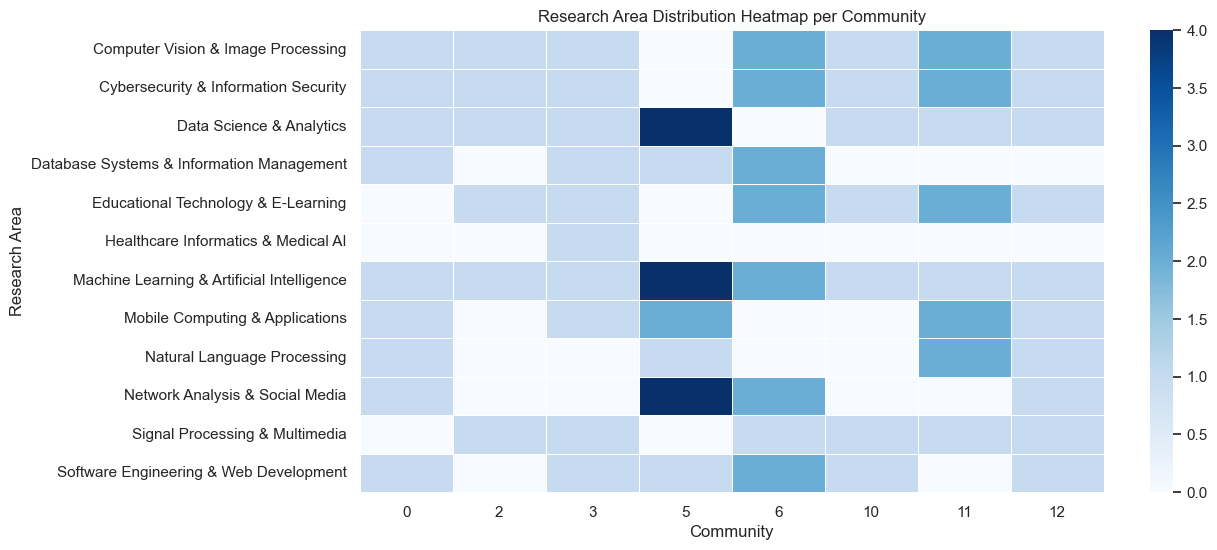

In [99]:
pivot_table = df.pivot(index="research_area", columns="leiden_community", values="cnt").fillna(0)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="Blues", linewidths=0.5)
plt.xlabel("Community")
plt.ylabel("Research Area")
plt.title("Research Area Distribution Heatmap per Community")
plt.show()

Drop the projection from the graph catalogue to free up resources

In [100]:
G.drop()

graphName                                      dosen_similarity_projection
database                                                       datascience
databaseLocation                                                     local
memoryUsage                                                               
sizeInBytes                                                             -1
nodeCount                                                               13
relationshipCount                                                      156
configuration            {'relationshipProjection': {'SIMILAR_RESEARCH'...
density                                                                1.0
creationTime                           2025-09-27T20:41:42.331832200+07:00
modificationTime                       2025-09-27T20:41:42.331832200+07:00
schema                   {'graphProperties': {}, 'nodes': {'Dosen': {}}...
schemaWithOrientation    {'graphProperties': {}, 'nodes': {'Dosen': {}}...
Name: 0, dtype: object

## Semantic Similar Research Area

Since the communities might not make perfect sense (due to the diversity of research areas), we can try similarity based on semantic meaning of research areas.

In [101]:
research_areas_df = gds.run_cypher(
    """
    MATCH (r:ResearchArea)
    RETURN r.name AS research_area
    """
)

In [102]:
research_areas_df.head(5)

,research_area
0,Computer Vision & Image Processing
1,Cybersecurity & Information Security
2,Data Science & Analytics
3,Database Systems & Information Management
4,Educational Technology & E-Learning


### STOP STOP STOP - DO NOT PROCEED (YET)

-- Only to be run by instructor (or if you have your own api key). Skip the following two cells -- 

In [ ]:
# skills_df['embedding'] = skills_df['description'].apply( lambda skill: embeddings.embed_documents([skill])[0])
# skills_df.head()

In [ ]:
# gds.run_cypher('''
#     unwind $data as row
#     match (s:Skill{name: row.skill})
#     set s.embedding = row.embedding
#     ''',
#     params = { 'data': skills_df.to_dict(orient='records') }
# )

In [ ]:
url = 'https://raw.githubusercontent.com/neo4j-product-examples/genai-workshop/refs/heads/main/talent/data/skills_embeddings.csv'

In [ ]:
skills_embeddings_df = pd.read_csv(url)

In [ ]:
skills_embeddings_df.head()

In [ ]:
type(skills_embeddings_df['Embedding'].iloc[0][0])

In [ ]:
skills_embeddings_df['Embedding'] = skills_embeddings_df['Embedding'].apply( lambda x: [ float(i) for i in x.strip("[]").split(", ")] )

In [ ]:
type(skills_embeddings_df['Embedding'].iloc[0][0])

In [ ]:
skills_embeddings_df.head()

Length of an embedding

In [ ]:
len(skills_embeddings_df['Embedding'].iloc[0])

### Add Embeddings to the database

Add embeddings with the description to Skill nodes in database

In [ ]:
for chunk in split_dataframe(skills_embeddings_df):
    records, summary, keys = driver.execute_query(
        """
        UNWIND $rows AS row
        MATCH (s:Skill{name: row.Skill})
        SET s.embedding = row.Embedding
        SET s.description = row.Description
        WITH s
        CALL db.create.setNodeVectorProperty(s, "embedding", s.embedding)
        RETURN COUNT(*) AS rows_processed
        """,
        database_=DATABASE,
        routing_=RoutingControl.WRITE,
        rows = chunk.to_dict('records')
    )

Let's have a look in the browser! 

### Vectors for Semantic Meaning

In [ ]:
driver.execute_query(
    """
    CREATE VECTOR INDEX `skill-embeddings` IF NOT EXISTS
    FOR (s:Skill) ON (s.embedding)
    OPTIONS {
        indexConfig: {
            `vector.dimensions`: 1536,
            `vector.similarity_function`: 'cosine'
        } 
    }
    """,
    database_=DATABASE,
    routing_=RoutingControl.WRITE
)      

In [ ]:
indexes_result_df  = driver.execute_query(
    'SHOW INDEXES',
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)
indexes_result_df

### Semantic Search

Take some Skill and find relevant other Skills: "Python", "Java", "Git", "CI/CD", "AWS", "Data Visualization", "Power BI", "R"". 

In [ ]:
skill_search = "Python"

In [ ]:
similar_skills_df  = driver.execute_query(
    """
    MATCH (s:Skill{name: $skill_search})
    CALL db.index.vector.queryNodes("skill-embeddings", 10, s.embedding) YIELD node, score
    WITH node as skill, score ORDER BY score DESC
    WHERE node.name <> s.name AND score > 0.9
    RETURN skill.name, score
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df(),
    skill_search = skill_search

)
similar_skills_df

We can also find similarity from other terms than the skills in the database now. 

In [ ]:
embeddings = OpenAIEmbeddings(model=EMBEDDINGS_MODEL)

Some suggestions to search for: 
- data visualizations and dashboards
- deployments
- API coding
- Machine Learning frameworks
- Cloud expertise

In [ ]:
skill_search = "API coding"

In [ ]:
driver.execute_query(
    '''
    CALL db.index.vector.queryNodes("skill-embeddings", 10, $query_vector) YIELD node, score
    WHERE score > 0.89
    RETURN node.name AS skill, score
    ''',
    database_ = DATABASE,
    routing_ = RoutingControl.READ,
    result_transformer_ = lambda r: r.to_df(),
    query_vector = embeddings.embed_query(skill_search)
)

Create relationship for similar sematic skills

In [ ]:
driver.execute_query(
    """
    CALL apoc.periodic.iterate(
        "MATCH (skill1:Skill) RETURN skill1",
        "WITH skill1 
        CALL db.index.vector.queryNodes('skill-embeddings', 10, skill1.embedding) YIELD node, score
        WITH skill1, node as skill2, score ORDER BY score DESC
        WHERE skill1.name < skill2.name AND score > 0.92
        MERGE (skill1)-[s:SIMILAR_SEMANTIC]->(skill2)
        SET s.score = score   
        ",
        {batchSize: 1000}
    )
    """,
    database_=DATABASE,
    routing_=RoutingControl.WRITE,
    result_transformer_= lambda r: r.to_df()
)

Let's look in the browser how these relationships look like. 

```MATCH p=()-[:SIMILAR_SEMANTIC]->() RETURN p```

What are similar skills in the database now? 

In [ ]:
similar_skills_df  = driver.execute_query(
    """
    MATCH (s1:Skill)-[r:SIMILAR_SEMANTIC]-(s2:Skill)
    WHERE s1.name < s2.name
    RETURN s1.name AS skill1, r.score AS score, s2.name AS skill2
    ORDER BY score DESC
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [ ]:
similar_skills_df

## Now we can find more people with based on Semantic Similarity

Check the following in the browser:
```
MATCH (p1:Person {name: "John Garcia"})-[:KNOWS]->(s:Skill)
WITH p1, COLLECT(s.name) as skills_1
CALL (p1, p1){
  MATCH p=(p1)-[:KNOWS]->(s1:Skill)-[r:SIMILAR_SEMANTIC]-(s2:Skill)<-[:KNOWS]-(p2:Person)
  RETURN p
  UNION 
  MATCH (p1)-[r:SIMILAR_SKILLSET]->(p2:Person), p=(p2)-[:KNOWS]->(:Skill)
  RETURN p
}
RETURN p
```

The following persons give some interesting results: "Amelia Davis", "Victoria Thomas", "John Walker"

In [ ]:
person_name_1 = "John Garcia"

In [ ]:
similar_persons_df  = driver.execute_query(
    """
    MATCH (p1:Person {name: $person_name_1})-[:KNOWS]->(s:Skill)
    WITH p1, COLLECT(s.name) as skills_1
    CALL (p1){
      MATCH (p1)-[:KNOWS]->(s1:Skill)-[r:SIMILAR_SEMANTIC]-(s2:Skill)<-[:KNOWS]-(p2:Person)
      RETURN p1 as person_1, p2 as person_2, SUM(r.score) AS score
      UNION 
      MATCH (p1)-[r:SIMILAR_SKILLSET]->(p2:Person)
      RETURN p1 as person_1, p2 AS person_2, SUM(r.overlap) AS score
    }
    WITH person_1.name as person_1, skills_1, person_2, SUM(score) as score
    WHERE score >= 1
    MATCH (person_2)-[:KNOWS]->(s:Skill)
    RETURN person_1, skills_1,  person_2.name as person_2, COLLECT(s.name) as skills_2, score
    ORDER BY score DESC
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df(),
    person_name_1 = person_name_1
)

In [ ]:
similar_persons_df

Check in the browser the following: 

```
MATCH p=(p1:Person {name: "John Garcia"})-[:KNOWS]->(s:Skill)-[:SIMILAR_SEMANTIC]->(:Skill)<-[:KNOWS]-(p2:Person{name:"Matthew Miller"})
RETURN p 
UNION 
MATCH p=(p1:Person {name: "John Garcia"})-[:KNOWS]->(s:Skill)<-[:KNOWS]-(p2:Person{name:"Matthew Miller"})
RETURN p
```

```
MATCH p=(p1:Person {name: "John Garcia"})-[:KNOWS]->(s:Skill)-[:SIMILAR_SEMANTIC*0..2]->(:Skill)<-[:KNOWS]-(p2:Person{name:"Matthew Miller"})
RETURN p 
UNION 
MATCH p=(p1:Person {name: "John Garcia"})-[:KNOWS]->(s:Skill)<-[:KNOWS]-(p2:Person{name:"Matthew Miller"})
RETURN p
```

Calculate for all of them with score > 3

In [ ]:
similar_persons_df  = driver.execute_query(
    """
    MATCH (p1:Person)-[:KNOWS]->(s:Skill)
    WITH p1, COLLECT(s.name) as skills_1
    CALL (p1, p1){
      MATCH (p1)-[:KNOWS]->(s1:Skill)-[r:SIMILAR_SEMANTIC]-(s2:Skill)<-[:KNOWS]-(p2:Person)
      RETURN p1 as person_1, p2 as person_2, SUM(r.score) AS score
      UNION 
      MATCH (p1)-[r:SIMILAR_SKILLSET]-(p2:Person)
      RETURN p1 as person_1, p2 AS person_2, SUM(r.overlap) AS score
    }
    WITH person_1.name as person_1, skills_1, person_2, SUM(score) as score
    WHERE score > 3
    MATCH (person_2)-[:KNOWS]->(s:Skill)
    RETURN person_1, skills_1,  person_2.name as person_2, COLLECT(s.name) as skills_2, score
    ORDER BY score DESC
    """,
    database_=DATABASE,
    routing_=RoutingControl.READ,
    result_transformer_= lambda r: r.to_df()
)

In [ ]:
similar_persons_df